# ANALYSIS 1. Honda Differential Flux Analysis
---
This notebook analyzes the differential atmospheric-neutrino flux files generated by `notebooks/runs/atmosphere/atmosphere1_honda_diff_flux_generation.py`.

The workflow follows the next analysis: 
- Load grouped particle data
- Check height-profile normalization
- Compare spectra
- Visualize height-energy maps
- Study angular dependence
- Inspect fluxes as functions of atmospheric depth `X` when the saved metadata contains the corresponding Honda depth grids.


## 1. Libraries

The package loader `tpeanuts.io.io_atmosphere.load_directory` is used so the notebook reads the same torch format produced by the Run1 generator. 


In [33]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import torch
import pandas as pd
from IPython.display import display

from tpeanuts.io.io_atmosphere import load_directory

from tpeanuts.util.notebooks import find_repo_root, save_and_show, save_figure, show_figure
from tpeanuts.util.atmosphere import angle_grid_for, particle_label
from tpeanuts.util.math import clamp_positive, nearest_index, selected_indices
from tpeanuts.util.type import get_entry_tensor, to_numpy
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

plt.rcParams.update({
    "figure.figsize": (8.5, 5.0),
    "axes.grid": True,
    "grid.alpha": 0.3,
})



PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts


## 2. Analysis Parameters

The default directory is the Run1 Honda output. The particle and plotting parameters below are intentionally centralized so each section can be rerun after changing the selected particle, energy, angle, or height.


### 2.1. Paths

All notebook outputs are rooted at `DEFAULT_OUTPUT_ROOT` unless `TPEANUTS_OUTPUT_ROOT` is defined in the environment. Figures are saved under the notebook-specific `OUTPUT_DIR`; display behavior is controlled in Section 2.2.


In [34]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ATMOSPHERE / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ATMOSPHERE / "honda")

OUTPUT_DIR = OUTPUT_ANALYSIS_ATMOSPHERE / "analysis_atmospher1_honda_flux"

DATA_MCEQ_ROOT = OUTPUT_DATA_MCEQ
DATA_HONDA_ROOT = OUTPUT_DATA_HONDA
INPUT_DATA_DIR = str(OUTPUT_DATA_HONDA / "test")
OUTPUT_DATA_DIR = OUTPUT_DIR

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)


Output root     : V:\output
Output directory: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux


### 2.2. Configuration Parameters

These parameters control tensor loading, the default particle and grid points used by the diagnostic plots, and the numerical safeguards used in log-scale and normalization checks. Change them here before executing the analysis cells below.


In [35]:
DEVICE = "cpu"
DTYPE = torch.float64
GROUP_BY = "particle"

SHOW_PLOTS = True

DEFAULT_PARTICLE = "numu"
DEFAULT_ENERGY_GEV = 10.0
DEFAULT_THETA_DEG = 45.0
DEFAULT_HEIGHT_KM = 15.0

ENERGY_GEV_LIST = [0.5, 1.0, 2.0, 5.0, 10.0, 50.0]
THETA_DEG_LIST = [0.0, 30.0, 45.0, 60.0, 75.0]
HEIGHT_KM_LIST = [0.0, 5.0, 10.0, 15.0, 20.0, 30.0]

N_ANGLE_CURVES = 6
N_ENERGY_CURVES = 6
EPS = 1.0e-300

ROBUSTNESS_PARTICLES = ["nue", "numu", "nutau", "antinue", "antinumu", "antinutau"]
ROBUSTNESS_ANGLE_MODE = "solid_angle"  # "solid_angle" uses sin(theta)dtheta; "linear" uses dtheta.
ROBUSTNESS_EPS = EPS

print("Device         :", DEVICE)
print("Dtype          :", DTYPE)
print("Group by       :", GROUP_BY)
print("Default particle:", DEFAULT_PARTICLE)


Device         : cpu
Dtype          : torch.float64
Group by       : particle
Default particle: numu


## 3. Load Run1 Flux Data

`load_directory` reconstructs one dictionary item per particle. Each item contains common grids and tensors stacked along the angle axis:

- `phi_E_theta_h`: differential flux in production height, shape `(n_theta, n_E, n_h)`.
- `phi_E_theta`: height-integrated flux, shape `(n_theta, n_E)`.
- `f_theta_E_h`: normalized production profile, shape `(n_theta, n_E, n_h)`.


In [36]:
data = load_directory(
    str(INPUT_DATA_DIR),
    map_location=DEVICE,
    dtype=DTYPE,
    device=DEVICE,
    group_by=GROUP_BY,
    verbose=True,
)

print(f"\nLoaded {len(data)} particle groups from {INPUT_DATA_DIR}")
print("\nAvailable particles:", list(data.keys()))


Loaded antinue      | n_theta =  10 | phi(E,theta,h) shape = (10, 101, 501)
Loaded antinumu     | n_theta =  10 | phi(E,theta,h) shape = (10, 101, 501)
Loaded antinutau    | n_theta =  10 | phi(E,theta,h) shape = (10, 101, 501)
Loaded nue          | n_theta =  10 | phi(E,theta,h) shape = (10, 101, 501)
Loaded numu         | n_theta =  10 | phi(E,theta,h) shape = (10, 101, 501)
Loaded nutau        | n_theta =  10 | phi(E,theta,h) shape = (10, 101, 501)

Loaded 6 particle groups from V:\output\data\atmosphere\honda\test

Available particles: ['antinue', 'antinumu', 'antinutau', 'nue', 'numu', 'nutau']


## 4. Dataset Inventory

This summary adds consistency checks between the saved height-differential flux and the height-integrated flux.


In [37]:
def summarize_group(name, group):
    E = group["E_grid_GeV"]
    h = group["h_grid_km"]
    theta = group["theta_grid_deg"]
    angle_name, angle_grid = angle_grid_for(group)
    phi_h = group["phi_E_theta_h"]
    phi = group["phi_E_theta"]
    f = group["f_theta_E_h"]

    f_norm = torch.trapezoid(f, x=h, dim=-1)
    phi_from_h = torch.trapezoid(phi_h, x=h, dim=-1)
    positive = phi[phi > 0.0]
    flux_threshold = torch.max(positive) * 1.0e-20 if positive.numel() > 0 else torch.tensor(0.0, dtype=phi.dtype)
    valid = phi > flux_threshold

    norm_err = torch.max(torch.abs(f_norm[valid] - 1.0)).item() if torch.any(valid) else 0.0
    flux_err = (
        torch.max(torch.abs(phi_from_h[valid] - phi[valid]) / torch.clamp(phi[valid], min=1.0e-300)).item()
        if torch.any(valid)
        else 0.0
    )

    print(f"\nParticle: {name}")
    print(f"  E grid       : {E.numel():5d} | [{float(E.min()):.3e}, {float(E.max()):.3e}] GeV")
    print(f"  h grid       : {h.numel():5d} | [{float(h.min()):.2f}, {float(h.max()):.2f}] km")
    print(f"  theta grid   : {theta.numel():5d} | [{float(theta.min()):.2f}, {float(theta.max()):.2f}] deg")
    print(f"  {angle_name} grid   : {angle_grid.numel():5d} | [{float(angle_grid.min()):.2f}, {float(angle_grid.max()):.2f}] deg")
    print(f"  phi shape    : {tuple(phi_h.shape)}")
    print(f"  max norm err : {norm_err:.3e}")
    print(f"  max flux err : {flux_err:.3e}")


def summarize_dataset(data):
    print("Dataset summary\n" + "-" * 72)
    for name, group in sorted(data.items()):
        summarize_group(name, group)

summarize_dataset(data)


Dataset summary
------------------------------------------------------------------------

Particle: antinue
  E grid       :   101 | [1.000e-01, 1.000e+04] GeV
  h grid       :   501 | [0.00, 120.00] km
  theta grid   :    10 | [18.19, 87.13] deg
  theta grid   :    10 | [18.19, 87.13] deg
  phi shape    : (10, 101, 501)
  max norm err : 1.277e-08
  max flux err : 6.581e-08

Particle: antinumu
  E grid       :   101 | [1.000e-01, 1.000e+04] GeV
  h grid       :   501 | [0.00, 120.00] km
  theta grid   :    10 | [18.19, 87.13] deg
  theta grid   :    10 | [18.19, 87.13] deg
  phi shape    : (10, 101, 501)
  max norm err : 1.069e-08
  max flux err : 6.497e-08

Particle: antinutau
  E grid       :   101 | [1.000e-01, 1.000e+04] GeV
  h grid       :   501 | [0.00, 120.00] km
  theta grid   :    10 | [18.19, 87.13] deg
  theta grid   :    10 | [18.19, 87.13] deg
  phi shape    : (10, 101, 501)
  max norm err : 0.000e+00
  max flux err : 0.000e+00

Particle: nue
  E grid       :   101 | [1.0

## 5. Normalization Check at One Grid Point

For a selected `(theta, E)` point, the production profile should satisfy `int f(h|E,theta) dh = 1`, and the differential flux should recover `phi(E,theta)` when integrated over height.


In [38]:
def check_normalization_height_profile(data, theta_deg=DEFAULT_THETA_DEG, energy_GeV=DEFAULT_ENERGY_GEV, debug = False):
    results = {}
    
    print(f'Check Height-Profile Normalization ')
    
    print('*'*90)
    for particle, group in sorted(data.items()):
        E = group["E_grid_GeV"]
        h = group["h_grid_km"]
        theta = group["theta_grid_deg"]
        i_theta = nearest_index(theta, theta_deg)
        i_E = nearest_index(E, energy_GeV)

        f = group["f_theta_E_h"][i_theta, i_E]
        phi_h = group["phi_E_theta_h"][i_theta, i_E]
        phi_ref = group["phi_E_theta"][i_theta, i_E]

        norm_f = torch.trapezoid(f, x=h)
        recovered_phi = torch.trapezoid(phi_h, x=h)
        rel_error = torch.abs(recovered_phi - phi_ref) / torch.clamp(torch.abs(phi_ref), min=1.0e-300)

        results[particle] = {
            "theta_deg": float(theta[i_theta]),
            "energy_GeV": float(E[i_E]),
            "norm_f": float(norm_f),
            "recovered_phi": float(recovered_phi),
            "phi_ref": float(phi_ref),
            "relative_error": float(rel_error),
        }

        print(
            f"{particle:12s} | theta={float(theta[i_theta]):7.3f} deg | "
            f"E={float(E[i_E]):6.3g} GeV | norm f={float(norm_f):.6f} | "
            f"rel err={float(rel_error):.3e}"
        )

    return results

normalization_results = check_normalization_height_profile(data,
                                                           theta_deg=DEFAULT_THETA_DEG, 
                                                           energy_GeV=DEFAULT_ENERGY_GEV, 
                                                           debug = True
                                                          )


Check Height-Profile Normalization 
******************************************************************************************
antinue      | theta= 41.410 deg | E=    10 GeV | norm f=1.000000 | rel err=2.392e-09
antinumu     | theta= 41.410 deg | E=    10 GeV | norm f=1.000000 | rel err=2.193e-08
antinutau    | theta= 41.410 deg | E=    10 GeV | norm f=1.000000 | rel err=0.000e+00
nue          | theta= 41.410 deg | E=    10 GeV | norm f=1.000000 | rel err=3.049e-08
numu         | theta= 41.410 deg | E=    10 GeV | norm f=1.000000 | rel err=2.662e-08
nutau        | theta= 41.410 deg | E=    10 GeV | norm f=1.000000 | rel err=0.000e+00


## 6. Differential Flux Slices

The next function shows either the differential flux `Phi(E,theta,h)` or the normalized production profile `f(h|E,theta)` by setting `profile=True`.


In [39]:
def plot_flux_slices(
    data,
    particle=DEFAULT_PARTICLE,
    theta_deg=DEFAULT_THETA_DEG,
    energy_GeV=DEFAULT_ENERGY_GEV,
    height_km=DEFAULT_HEIGHT_KM,
    energy_GeV_list=ENERGY_GEV_LIST,
    theta_deg_list=THETA_DEG_LIST,
    height_km_list=HEIGHT_KM_LIST,
    profile=False,
    logy=True,
):
    group = data[particle]
    E = group["E_grid_GeV"]
    theta = group["theta_grid_deg"]
    h = group["h_grid_km"]
    Z = group["f_theta_E_h"] if profile else group["phi_E_theta_h"]

    i_theta_fixed = nearest_index(theta, theta_deg)
    i_E_fixed = nearest_index(E, energy_GeV)
    i_h_fixed = nearest_index(h, height_km)

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    ax11, ax12 = axes[0]
    ax21, ax22 = axes[1]

    ylabel = r"$f(h\mid E,	\theta)$" if profile else r"$\Phi(E,	\theta,h)$"
    title_word = "production profile" if profile else "differential flux"

    for energy in energy_GeV_list:
        i_E = nearest_index(E, energy)
        ax11.plot(h, Z[i_theta_fixed, i_E], linewidth=2, label=rf"$E={float(E[i_E]):.3g}$ GeV")
    ax11.set_xlabel("Production height h [km]")
    ax11.set_ylabel(ylabel)
    ax11.set_title(rf"{title_word} vs h, $\theta={float(theta[i_theta_fixed]):.1f}^\circ$")
    ax11.legend(fontsize=8)

    for th in theta_deg_list:
        i_th = nearest_index(theta, th)
        ax12.plot(h, Z[i_th, i_E_fixed], linewidth=2, label=rf"$\theta={float(theta[i_th]):.1f}^\circ$")
    ax12.set_xlabel("Production height h [km]")
    ax12.set_ylabel(ylabel)
    ax12.set_title(rf"{title_word} vs h, $E={float(E[i_E_fixed]):.3g}$ GeV")
    ax12.legend(fontsize=8)
    
    for energy in energy_GeV_list:
        i_E = nearest_index(E, energy)
        #ax21.semilogy(theta, clamp_positive(Z[:, i_E, i_h_fixed]), linewidth=2, label=rf"$E={float(E[i_E]):.3g}$ GeV")
        ax21.plot(theta, clamp_positive(Z[:, i_E, i_h_fixed]), linewidth=2, label=rf"$E={float(E[i_E]):.3g}$ GeV")
    ax21.set_xlabel(r"Surface angle $\theta$ [deg]")
    ax21.set_ylabel(ylabel)
    ax21.set_title(rf"{title_word} vs $\theta$, $h={float(h[i_h_fixed]):.1f}$ km")
    ax21.legend(fontsize=8)
    ax21.set_ylim(1.1*1e-3)
    
    for h_value in height_km_list:
        i_h = nearest_index(h, h_value)
        #ax22.semilogy(theta, clamp_positive(Z[:, i_E_fixed, i_h]), linewidth=2, label=rf"$h={float(h[i_h]):.1f}$ km")
        ax22.plot(theta, clamp_positive(Z[:, i_E_fixed, i_h]), linewidth=2, label=rf"$h={float(h[i_h]):.1f}$ km")
    ax22.set_xlabel(r"Surface angle $\theta$ [deg]")
    ax22.set_ylabel(ylabel)
    ax22.set_title(rf"{title_word} vs $\theta$, $E={float(E[i_E_fixed]):.3g}$ GeV")
    ax22.legend(fontsize=8)
    ax22.set_ylim(1.1*1e-3)
    
    if logy:
        ax11.set_yscale("log")
        ax12.set_yscale("log")

    fig.suptitle(f"{particle_label(particle)} | {title_word}", y=1.02, fontsize=14)
    fig.tight_layout()
    save_and_show(f"flux_slices_{particle}_{'profile' if profile else 'phi'}.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    return fig


Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\flux_slices_numu_profile.png


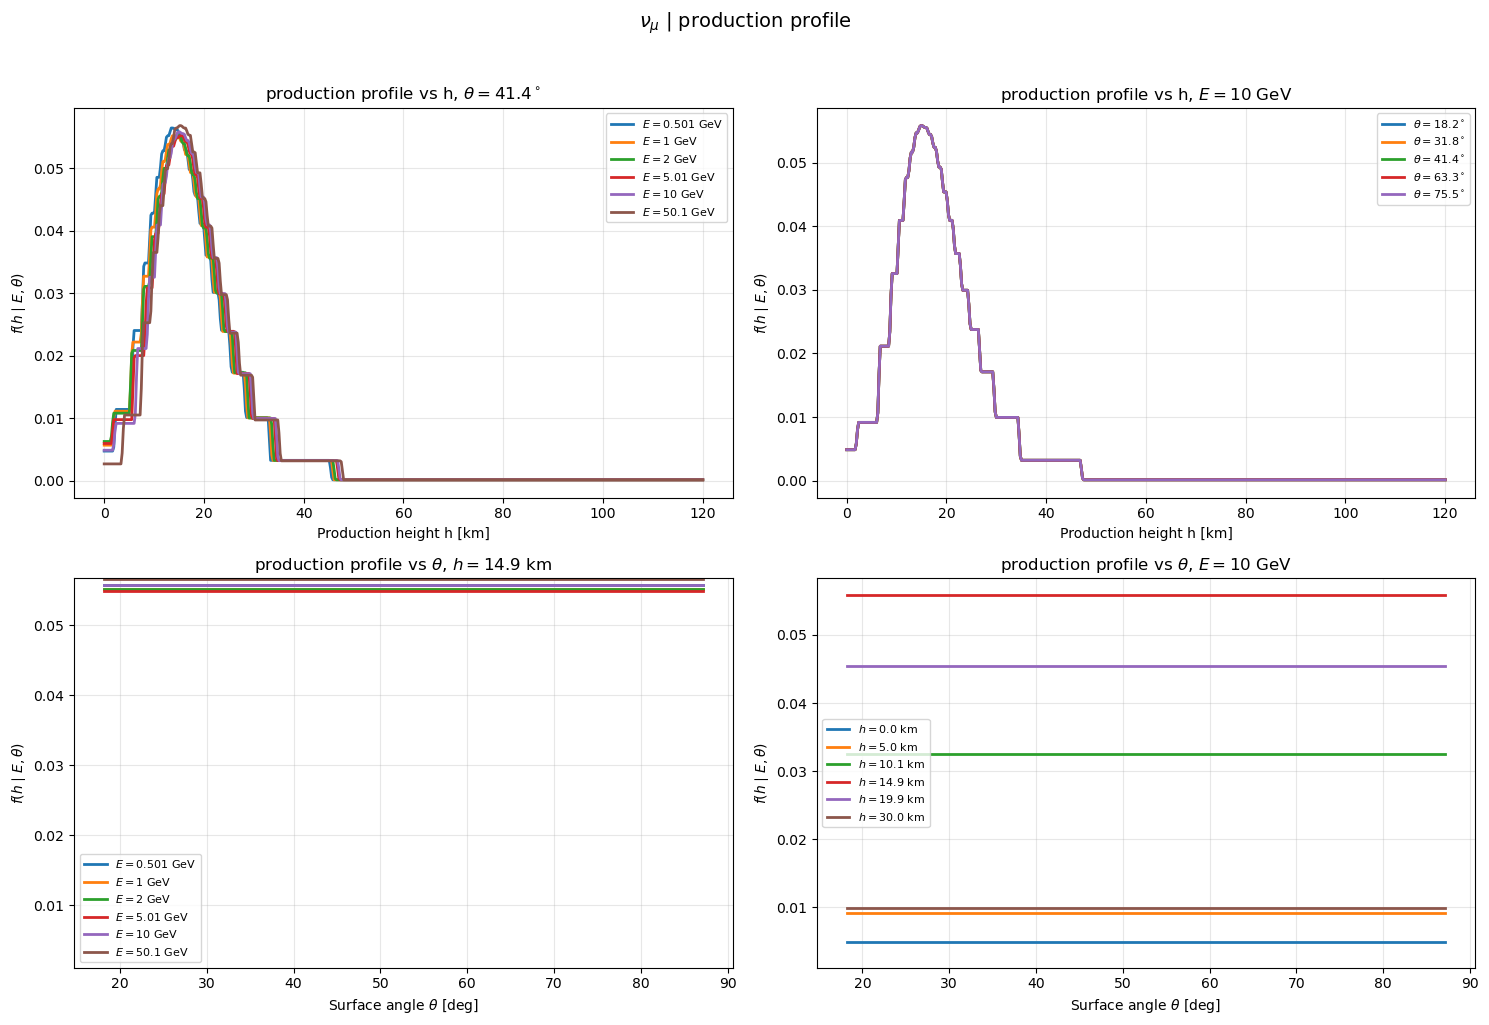

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\flux_slices_nue_profile.png


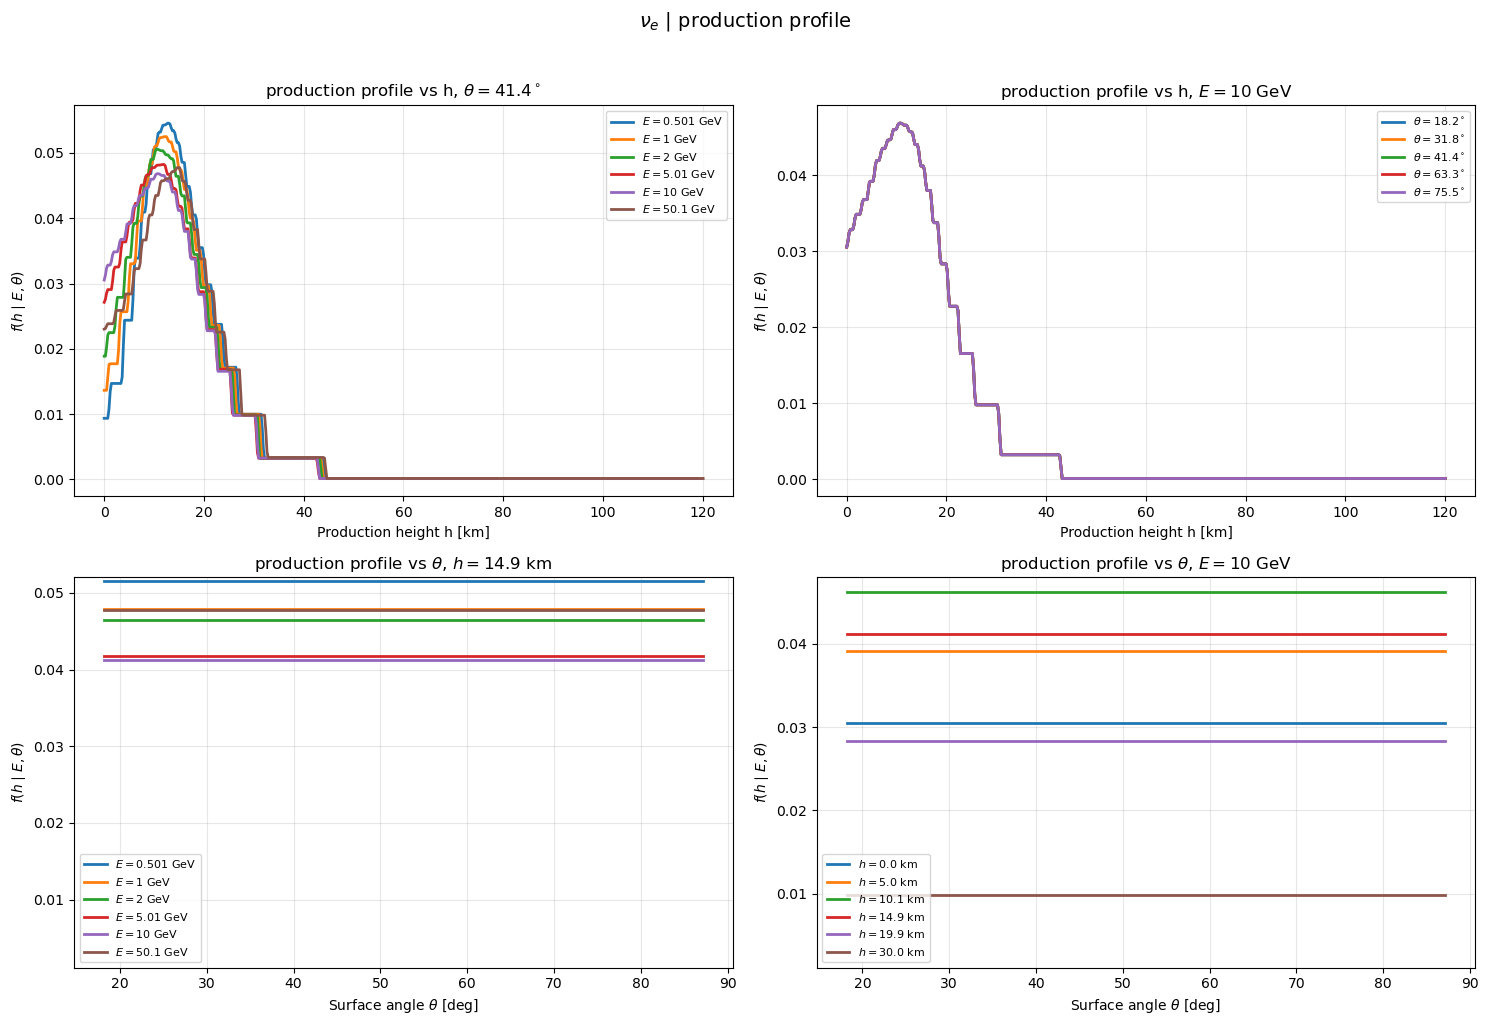

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\flux_slices_numu_phi.png


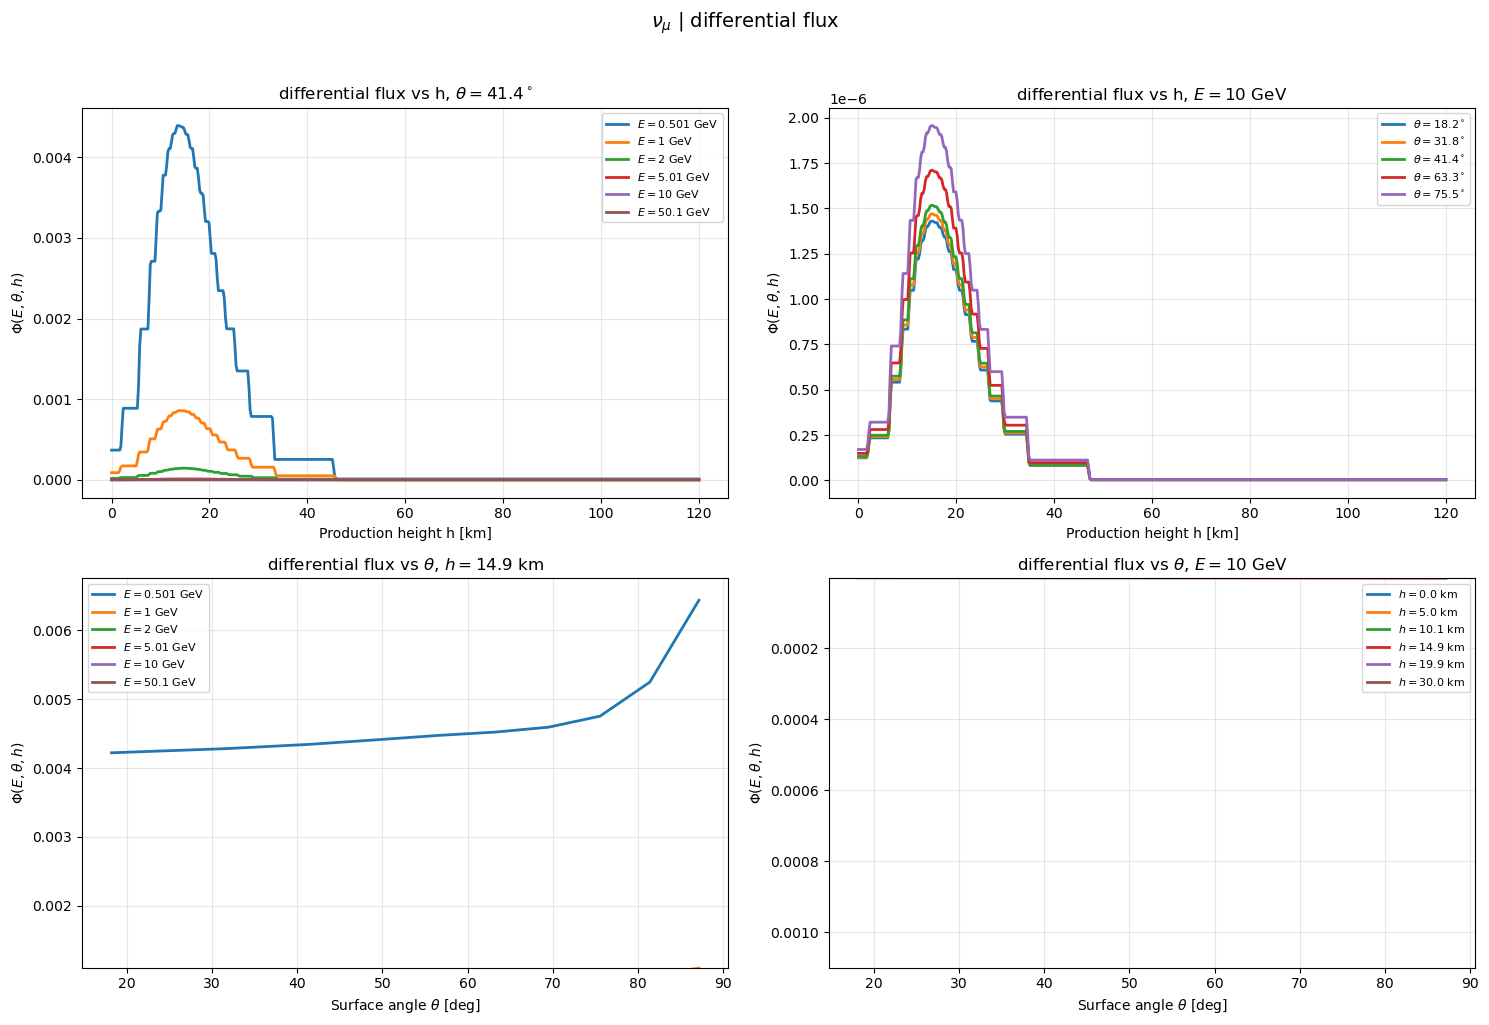

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\flux_slices_nue_phi.png


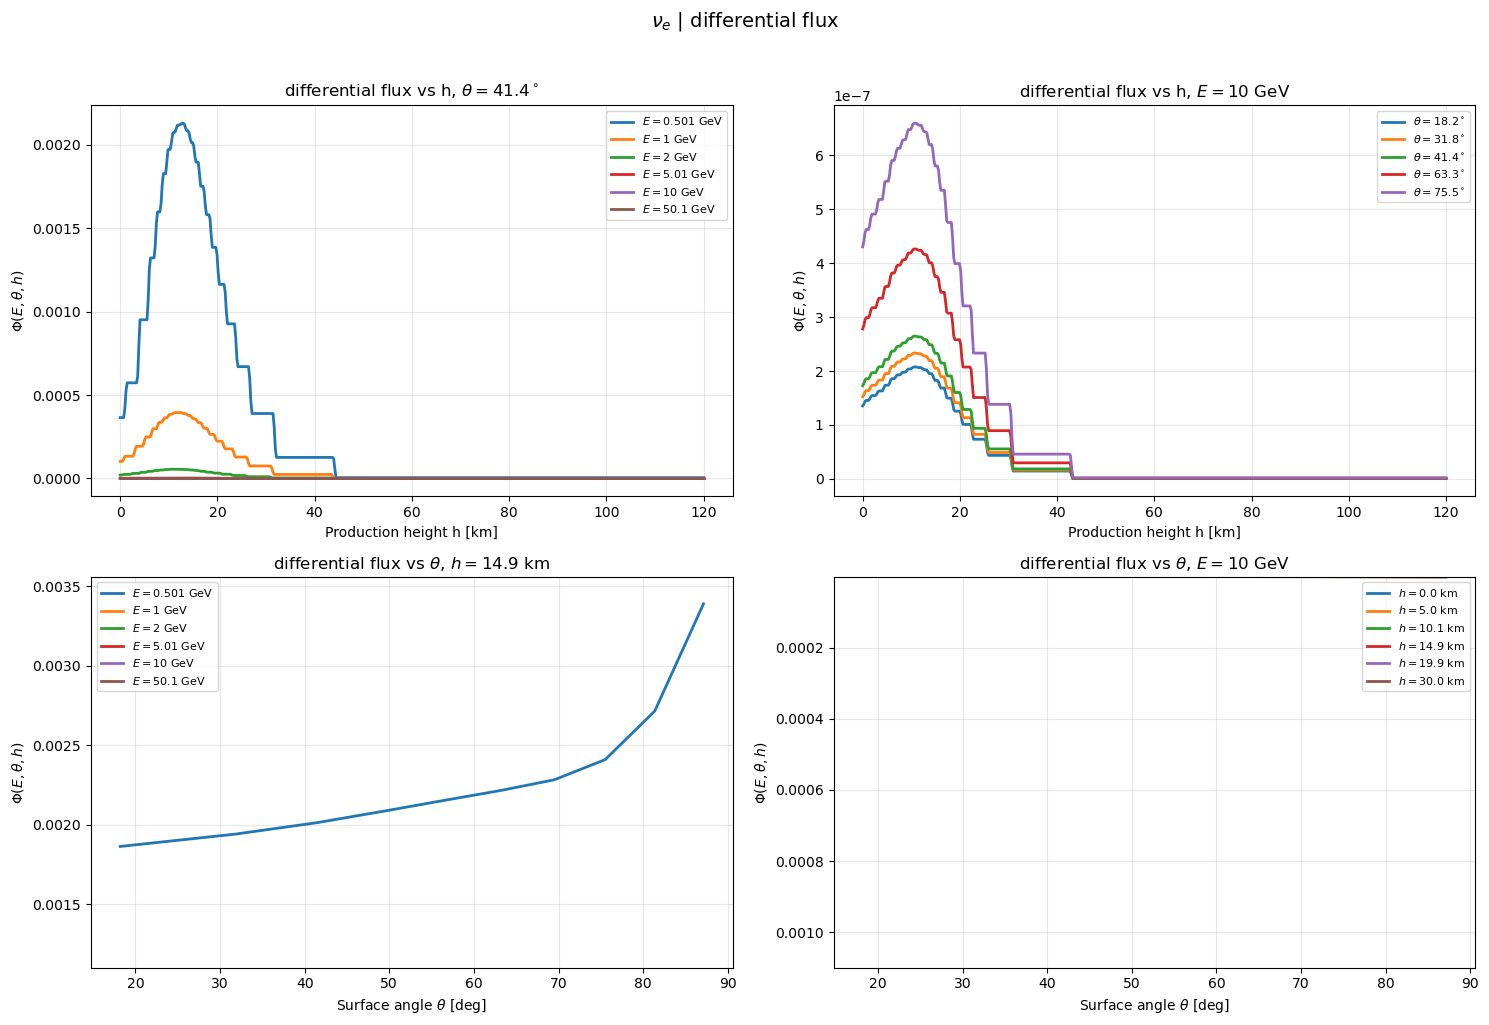

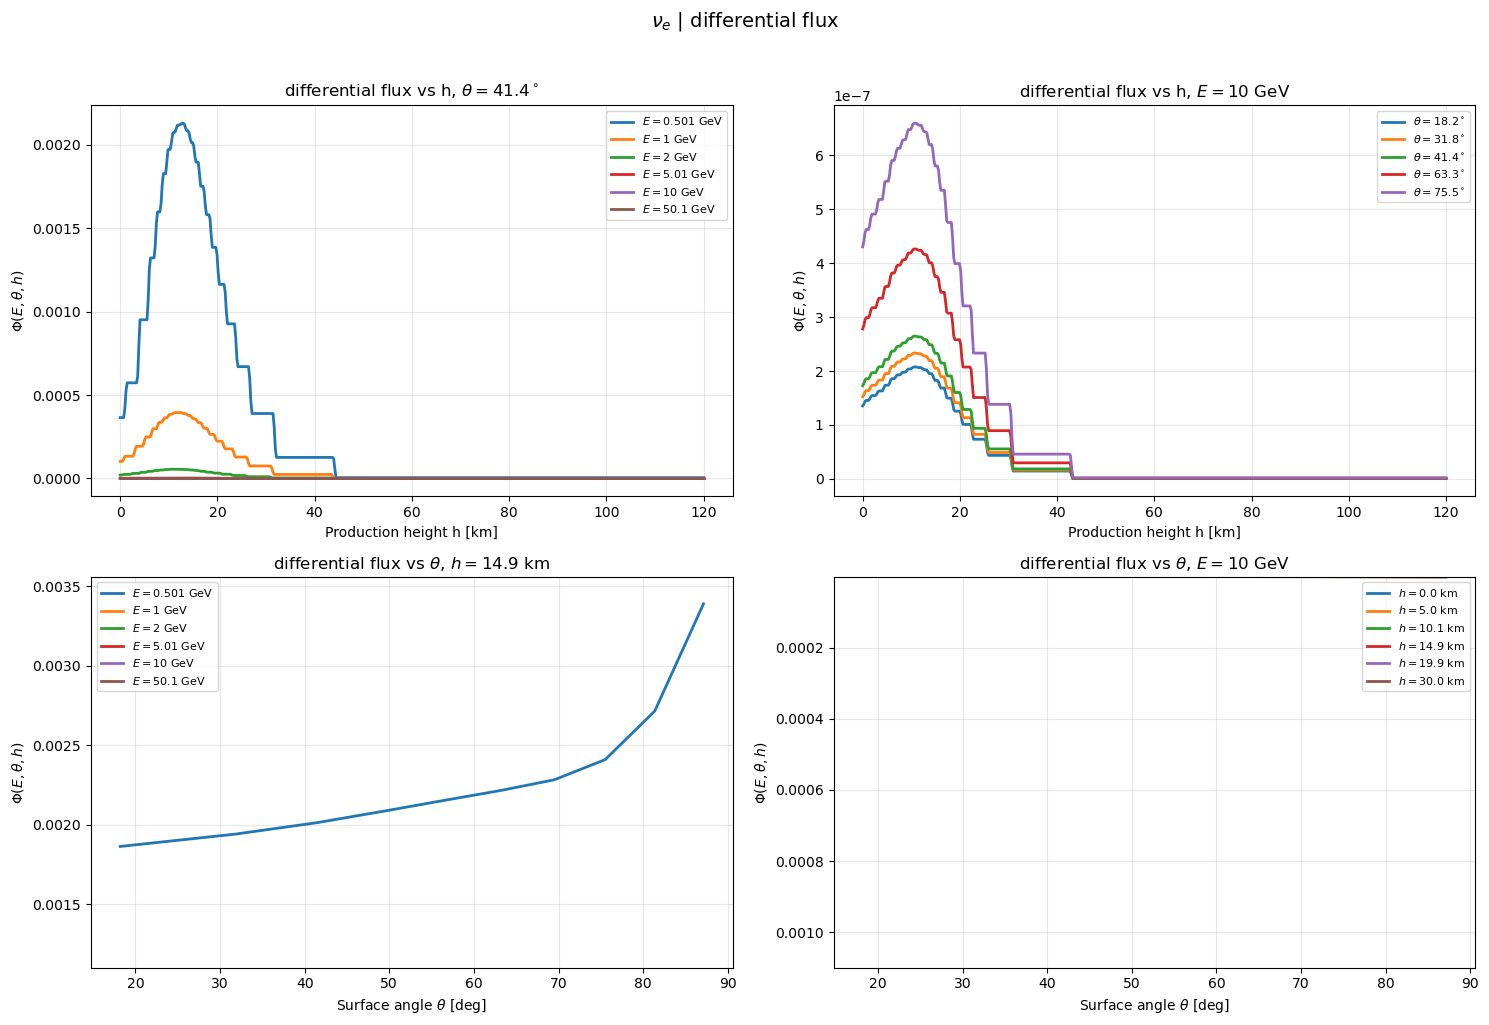

In [40]:
#plot_flux_slices(data, particle=DEFAULT_PARTICLE, profile=False)
plot_flux_slices(data, particle=DEFAULT_PARTICLE, profile=True, logy=False)
plot_flux_slices(data, particle="nue", profile=True, logy=False)
plot_flux_slices(data, particle=DEFAULT_PARTICLE, profile=False, logy=False)
plot_flux_slices(data, particle="nue", profile=False, logy=False)


## 7. Energy Spectra

Compare height-integrated spectra for several angles and, separately, the local height-differential spectrum at one production height.


In [41]:
def flavour_particles_for_mode(mode="nu"):
    if mode == "nu":
        return ["nue", "numu", "nutau"]
    if mode == "antinu":
        return ["antinue", "antinumu", "antinutau"]
    raise ValueError("mode must be 'nu' or 'antinu'.")


def plot_energy_spectrum(
    data,
    particle=DEFAULT_PARTICLE,
    theta_deg=DEFAULT_THETA_DEG,
    height_integrated=True,
    h_km=None,
    ax=None,
    label=None,
):
    group = data[particle]
    E = group["E_grid_GeV"]
    theta = group["theta_grid_deg"]
    h = group["h_grid_km"]
    i_theta = nearest_index(theta, theta_deg)

    owns_figure = ax is None
    if owns_figure:
        fig, ax = plt.subplots(figsize=(8.5, 5.0))
    else:
        fig = ax.figure

    if height_integrated:
        phi = group["phi_E_theta"][i_theta]
        quantity_label = rf"$\Phi(E,\theta={float(theta[i_theta]):.1f}^\circ)$"
        title_extra = "height integrated"
    else:
        if h_km is None:
            h_km = DEFAULT_HEIGHT_KM
        i_h = nearest_index(h, h_km)
        phi = group["phi_E_theta_h"][i_theta, :, i_h]
        quantity_label = rf"$\Phi(E,\theta={float(theta[i_theta]):.1f}^\circ,h={float(h[i_h]):.1f}\,\mathrm{{km}})$"
        title_extra = rf"at h={float(h[i_h]):.1f} km"

    ax.loglog(E, clamp_positive(phi), linewidth=2, label=label or quantity_label)
    ax.set_xlabel("Energy E [GeV]")
    ax.set_ylabel("Differential flux")
    ax.set_title(rf"{particle}: energy spectrum, {title_extra}")
    ax.legend()
    ax.set_xlim(1e-1, 5e+8)
    ax.set_ylim(1e-30, 1e2)

    if owns_figure:
        fig.tight_layout()
        save_and_show(f"energy_spectrum_{particle}_{'integrated' if height_integrated else 'height'}.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    return fig


def energy_spectrum_for_particle(data, particle, theta_deg=DEFAULT_THETA_DEG, height_integrated=True, h_km=None):
    group = data[particle]
    E = group["E_grid_GeV"]
    theta = group["theta_grid_deg"]
    h = group["h_grid_km"]
    i_theta = nearest_index(theta, theta_deg)

    if height_integrated:
        phi = group["phi_E_theta"][i_theta]
    else:
        if h_km is None:
            h_km = DEFAULT_HEIGHT_KM
        i_h = nearest_index(h, h_km)
        phi = group["phi_E_theta_h"][i_theta, :, i_h]

    return E, phi


def plot_flavour_and_total_energy_spectra(
    data,
    mode="nu",
    theta_deg=DEFAULT_THETA_DEG,
    height_integrated=True,
    h_km=None,
):
    particles = [particle for particle in flavour_particles_for_mode(mode) if particle in data]
    if len(particles) != 3:
        raise KeyError(f"Expected three particles for mode={mode!r}. Found: {particles}")

    spectra = []
    E_ref = None
    for particle in particles:
        E, phi = energy_spectrum_for_particle(
            data,
            particle,
            theta_deg=theta_deg,
            height_integrated=height_integrated,
            h_km=h_km,
        )
        if E_ref is None:
            E_ref = E
        elif not torch.allclose(E_ref, E):
            raise ValueError(f"Energy grid mismatch for {particle}.")
        spectra.append(phi)

    total = torch.stack(spectra, dim=0).sum(dim=0)
    labels = [particle_label(particle) for particle in particles] + ["total"]
    values = spectra + [total]

    fig, ax = plt.subplots(figsize=(8.8, 5.2))
    title_extra = "height integrated" if height_integrated else f"h={h_km or DEFAULT_HEIGHT_KM:.1f} km"
    for label, phi in zip(labels, values):
        linewidth = 2.8 if label == "total" else 2.0
        linestyle = ":" if label == "total" else "-"
        ax.loglog(E_ref, clamp_positive(phi), linewidth=linewidth, linestyle=linestyle, label=label)

    ax.set_xlabel("Energy E [GeV]")
    ax.set_ylabel("Differential flux")
    ax.set_title(rf"Energy spectra at $\theta\simeq {theta_deg:.1f}^\circ$, mode={mode}, {title_extra}")
    #ax.set_xlim(1e-1, 5e+8)
    #ax.set_ylim(1e-30, 1e2)
    ax.legend()
    fig.tight_layout()
    save_and_show(f"energy_spectra_{mode}_{'integrated' if height_integrated else 'height'}_flavours_total.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    return fig


def plot_spectra_by_angle(data, particle=DEFAULT_PARTICLE, max_angles=N_ANGLE_CURVES):
    group = data[particle]
    E = group["E_grid_GeV"]
    angle_name, angle_grid = angle_grid_for(group)
    phi = group["phi_E_theta"]

    fig, ax = plt.subplots(figsize=(8.5, 5.0))
    for idx in selected_indices(angle_grid.numel(), max_angles):
        idx = int(idx.item())
        ax.loglog(E, clamp_positive(phi[idx]), linewidth=2, label=rf"${angle_name}={float(angle_grid[idx]):.1f}^\circ$")
    ax.set_xlabel("Energy E [GeV]")
    ax.set_ylabel(r"$\Phi(E,\theta)$")
    ax.set_title(f"{particle}: height-integrated spectra by angle")
    ax.legend(fontsize=8)
    #ax.set_xlim(1e-0, 5e9)
    #ax.set_ylim(1e-40, 1e-1)

    fig.tight_layout()
    save_and_show(f"spectra_by_angle_{particle}.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    return fig


Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\energy_spectra_nu_integrated_flavours_total.png


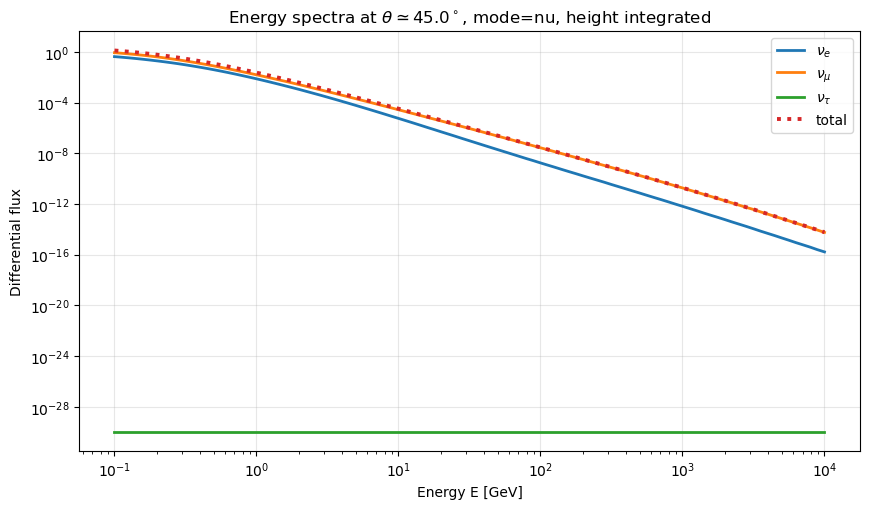

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\energy_spectra_nu_height_flavours_total.png


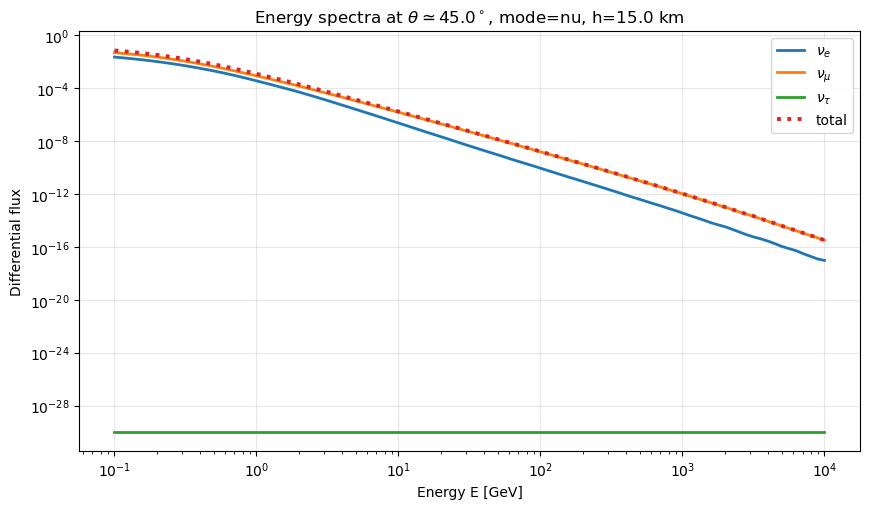

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\spectra_by_angle_numu.png


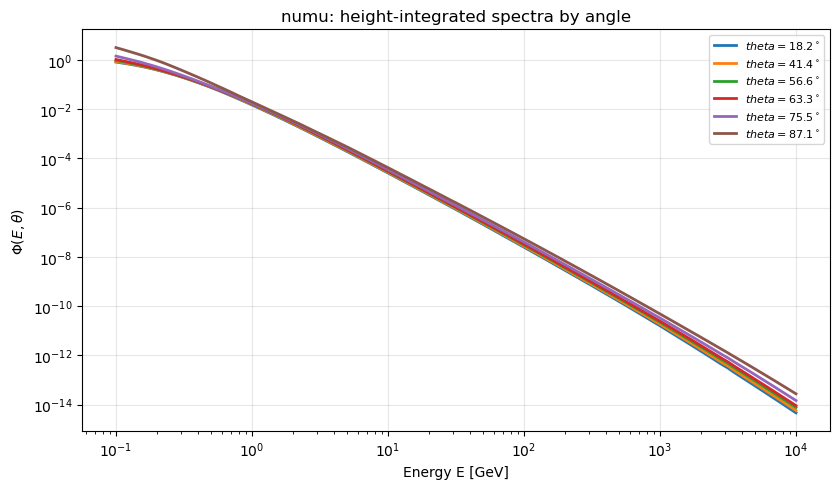

In [42]:
_ = plot_flavour_and_total_energy_spectra(data, mode="nu", height_integrated=True)
_ = plot_flavour_and_total_energy_spectra(data, mode="nu", height_integrated=False, h_km=DEFAULT_HEIGHT_KM)
_ = plot_spectra_by_angle(data, particle=DEFAULT_PARTICLE)


## 8. Height-Energy Maps

These maps show the two-dimensional structure in production height and energy for one angle.


In [43]:
def plot_height_energy_map(data, particle=DEFAULT_PARTICLE, theta_deg=DEFAULT_THETA_DEG, quantity="flux"):
    group = data[particle]
    E = group["E_grid_GeV"]
    h = group["h_grid_km"]
    theta = group["theta_grid_deg"]
    i_theta = nearest_index(theta, theta_deg)

    if quantity == "flux":
        Z = group["phi_E_theta_h"][i_theta]
        label = r"$\log_{10}\Phi(E,	\theta,h)$"
    elif quantity == "profile":
        Z = group["f_theta_E_h"][i_theta]
        label = r"$\log_{10}f(h\mid E,\theta)$"
    else:
        raise ValueError("quantity must be 'flux' or 'profile'.")

    Zlog = torch.log10(torch.clamp(Z, min=EPS))

    fig, ax = plt.subplots(figsize=(9.0, 5.2))
    mesh = ax.pcolormesh(h, E, Zlog, shading="auto")
    ax.set_yscale("log")
    ax.set_xlabel("Production height h [km]")
    ax.set_ylabel("Energy E [GeV]")
    ax.set_title(rf"{particle}: {quantity} map at $\theta={float(theta[i_theta]):.1f}^\circ$")
    fig.colorbar(mesh, ax=ax, label=label)
    fig.tight_layout()
    save_and_show(f"height_energy_map_{particle}_{quantity}.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    return fig


Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\height_energy_map_numu_flux.png


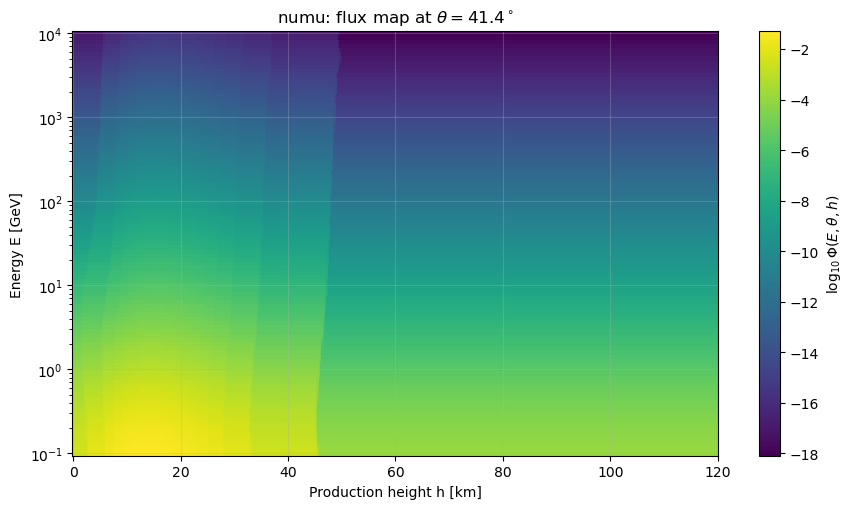

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\height_energy_map_numu_profile.png


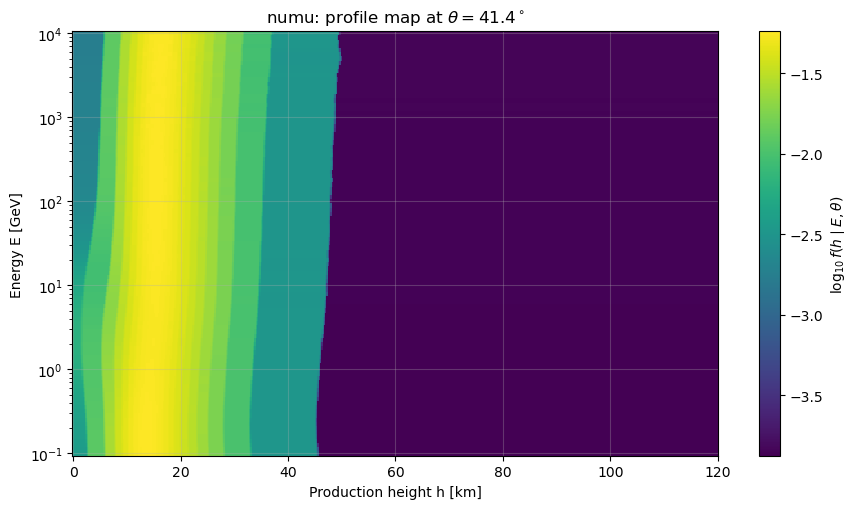

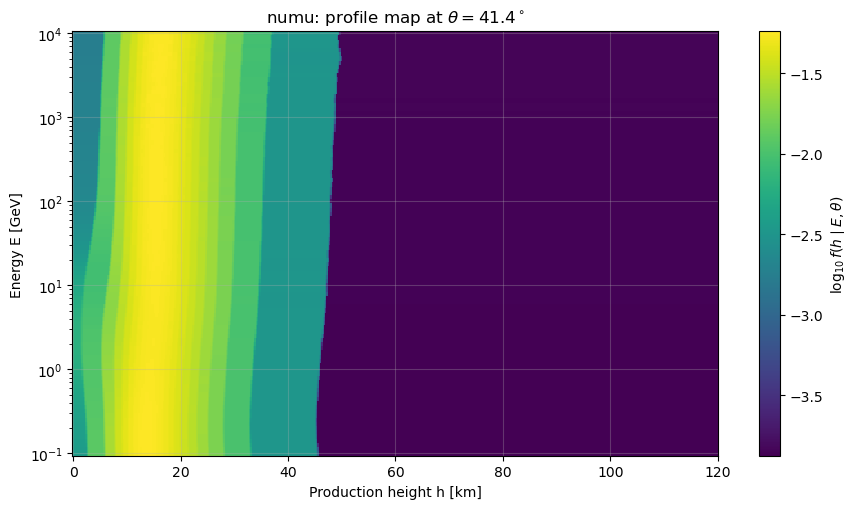

In [44]:
plot_height_energy_map(data, particle=DEFAULT_PARTICLE, quantity="flux")
plot_height_energy_map(data, particle=DEFAULT_PARTICLE, quantity="profile")


## 9. Particle Comparison

This section compares the height-integrated spectra of all loaded particle groups at one common angle.


Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\particle_comparison_energy_spectrum.png


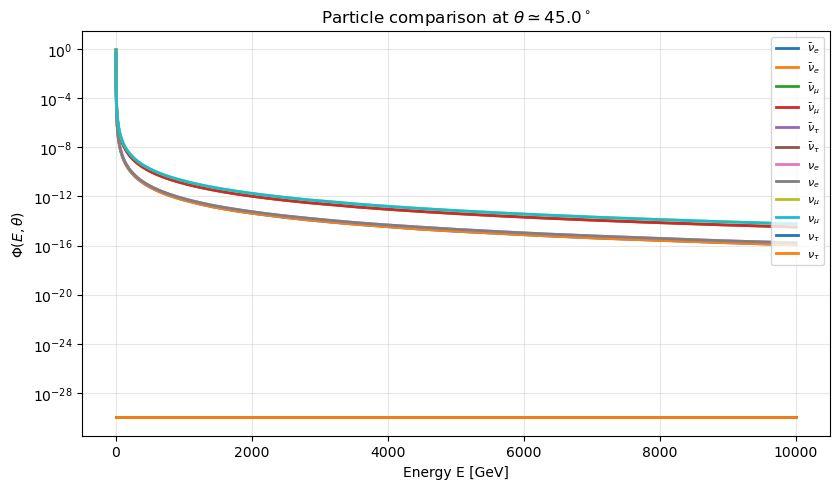

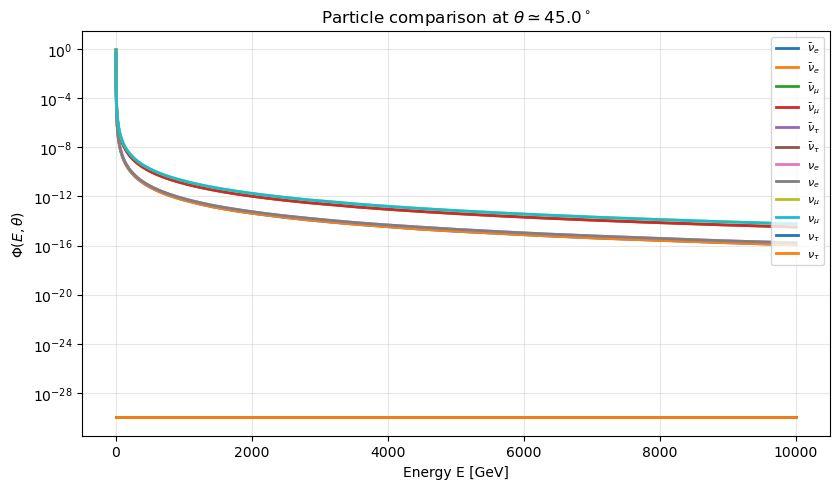

In [45]:
def plot_compare_particles_energy_spectrum(data, theta_deg=DEFAULT_THETA_DEG):
    fig, ax = plt.subplots(figsize=(8.5, 5.0))

    for particle, group in sorted(data.items()):
        E = group["E_grid_GeV"]
        theta = group["theta_grid_deg"]
        i_theta = nearest_index(theta, theta_deg)
        phi = group["phi_E_theta"][i_theta]
        ax.plot(E, clamp_positive(phi), linewidth=2, label=particle_label(particle))
        ax.plot(E, clamp_positive(phi), linewidth=2, label=particle_label(particle))
    ax.set_yscale("log")
    ax.set_xlabel("Energy E [GeV]")
    ax.set_ylabel(r"$\Phi(E,\theta)$")
    ax.set_title(rf"Particle comparison at $\theta\simeq {theta_deg:.1f}^\circ$")
    ax.legend(fontsize=8)
    fig.tight_layout()
    save_and_show("particle_comparison_energy_spectrum.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    return fig

plot_compare_particles_energy_spectrum(data)


## 10. Angular Dependence

For selected energies, inspect how the height-integrated flux changes with detector angle `alpha` when available, or with Honda surface angle `theta` otherwise.


Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\flux_vs_angle_numu.png


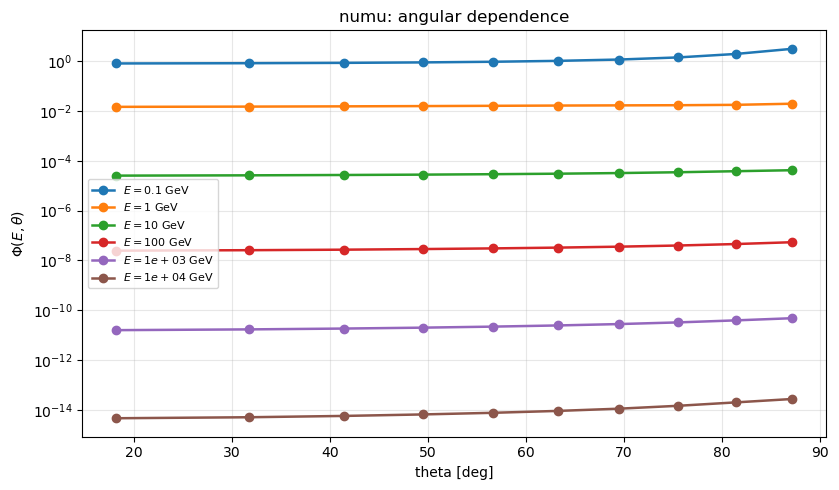

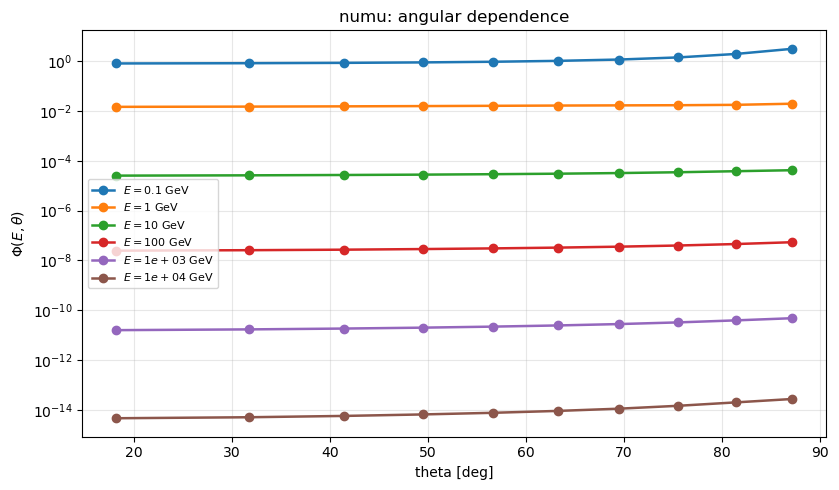

In [46]:
def plot_flux_vs_angle(data, particle=DEFAULT_PARTICLE, max_energies=N_ENERGY_CURVES):
    group = data[particle]
    E = group["E_grid_GeV"]
    angle_name, angle_grid = angle_grid_for(group)
    phi = group["phi_E_theta"]

    fig, ax = plt.subplots(figsize=(8.5, 5.0))
    for idx in selected_indices(E.numel(), max_energies):
        idx = int(idx.item())
        ax.semilogy(angle_grid, clamp_positive(phi[:, idx]), marker="o", linewidth=1.8, label=rf"$E={float(E[idx]):.3g}$ GeV")

    ax.set_xlabel(f"{angle_name} [deg]")
    ax.set_ylabel(r"$\Phi(E,\theta)$")
    ax.set_title(f"{particle}: angular dependence")
    ax.legend(fontsize=8)
    fig.tight_layout()
    save_and_show(f"flux_vs_angle_{particle}.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    return fig

plot_flux_vs_angle(data, particle=DEFAULT_PARTICLE)


## 11. Theta-Height Maps

At a fixed energy, these maps show how the production-height distribution changes across the angular grid.


Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\theta_height_map_numu_flux.png


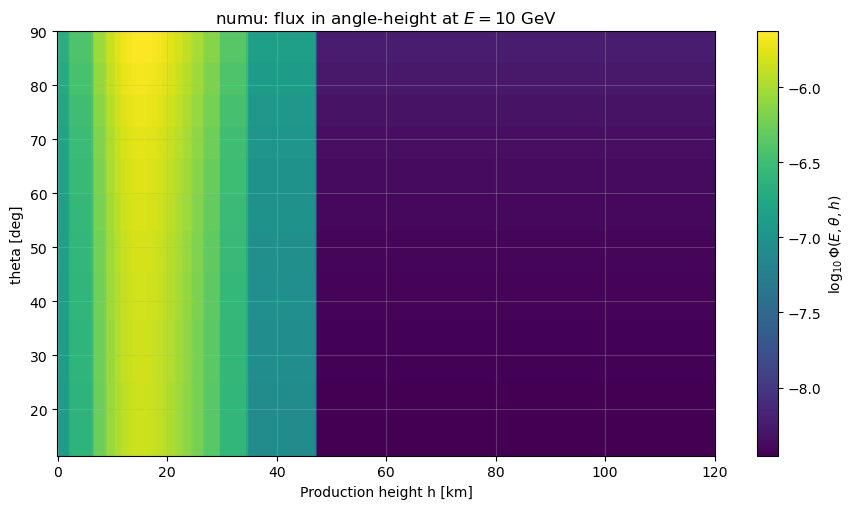

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\theta_height_map_numu_profile.png


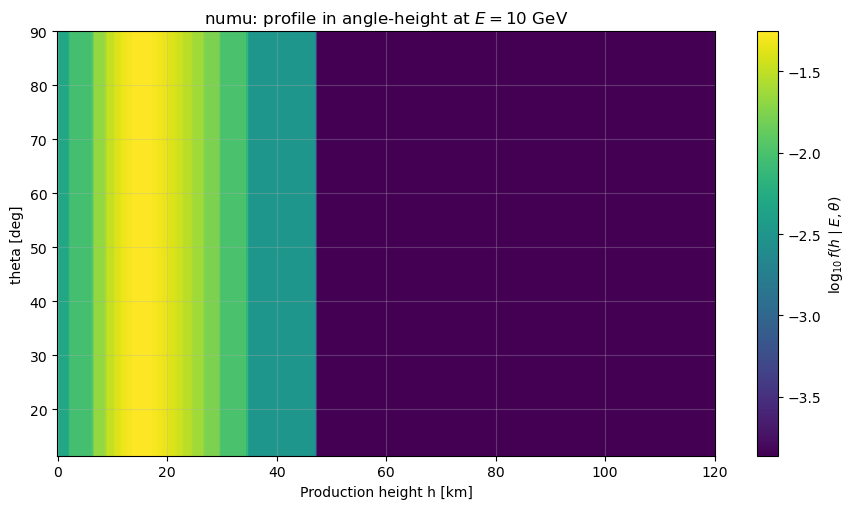

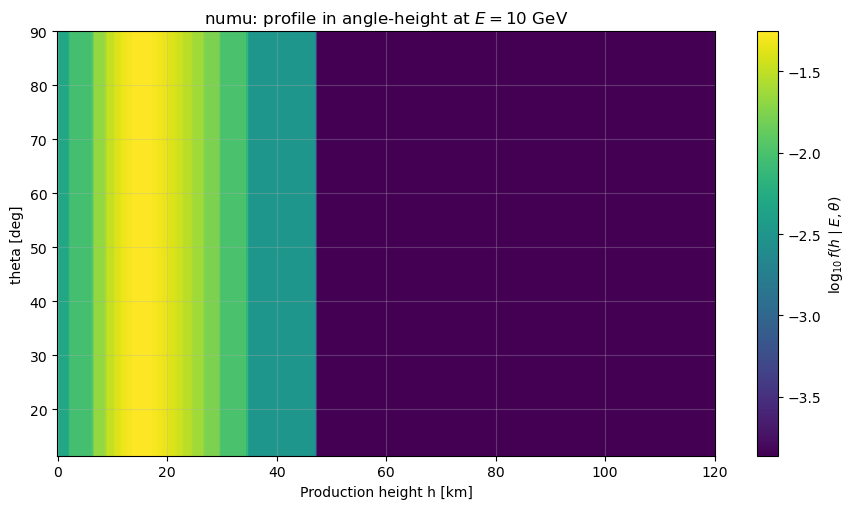

In [47]:
def plot_theta_height_flux_map(data, particle=DEFAULT_PARTICLE, energy_GeV=DEFAULT_ENERGY_GEV, quantity="flux"):
    group = data[particle]
    E = group["E_grid_GeV"]
    h = group["h_grid_km"]
    angle_name, angle_grid = angle_grid_for(group)
    i_E = nearest_index(E, energy_GeV)

    if quantity == "flux":
        Z = group["phi_E_theta_h"][:, i_E, :]
        label = r"$\log_{10}\Phi(E,\theta,h)$"
    elif quantity == "profile":
        Z = group["f_theta_E_h"][:, i_E, :]
        label = r"$\log_{10}f(h\mid E,\theta)$"
    else:
        raise ValueError("quantity must be 'phi' or 'profile'.")

    fig, ax = plt.subplots(figsize=(9.0, 5.2))
    mesh = ax.pcolormesh(h, angle_grid, torch.log10(torch.clamp(Z, min=EPS)), shading="auto")
    ax.set_xlabel("Production height h [km]")
    ax.set_ylabel(f"{angle_name} [deg]")
    ax.set_title(rf"{particle}: {quantity} in angle-height at $E={float(E[i_E]):.3g}$ GeV")
    fig.colorbar(mesh, ax=ax, label=label)
    fig.tight_layout()
    save_and_show(f"theta_height_map_{particle}_{quantity}.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    return fig

plot_theta_height_flux_map(data, particle=DEFAULT_PARTICLE, quantity="flux")
plot_theta_height_flux_map(data, particle=DEFAULT_PARTICLE, quantity="profile")


## 12. Polar View of Production Height

A polar plot is useful for visualizing the same angle-height information in a detector-oriented geometry. The radius is production height and the polar angle is the loaded detector angle `alpha` if present, otherwise the Honda `theta`.


Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\polar_theta_height_numu_flux.png


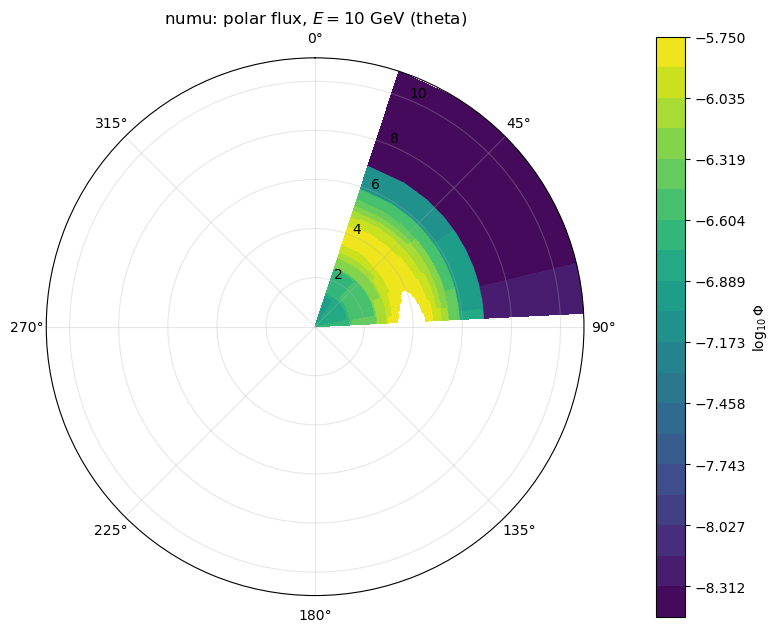

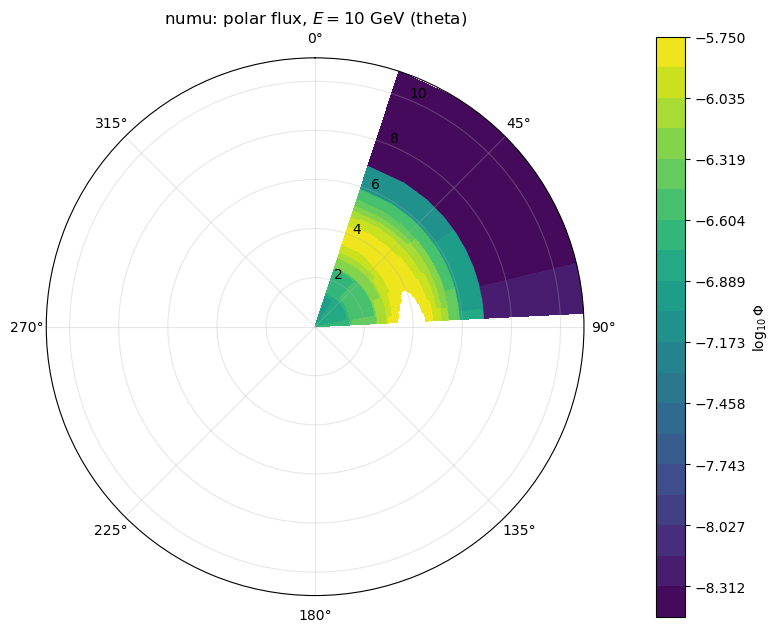

In [48]:
def plot_theta_height_flux_polar(
    data,
    particle=DEFAULT_PARTICLE,
    energy_GeV=DEFAULT_ENERGY_GEV,
    quantity="flux",
):

    group = data[particle]

    E = group["E_grid_GeV"]
    h = group["h_grid_km"]

    angle_name, angle_grid = angle_grid_for(group)

    i_E = nearest_index(E, energy_GeV)

    if quantity == "flux":
        Z = group["phi_E_theta_h"][:, i_E, :]
        label = r"$\log_{10}\Phi$"

    elif quantity == "profile":
        Z = group["f_theta_E_h"][:, i_E, :]
        label = r"$\log_{10}f$"

    else:
        raise ValueError("quantity must be 'flux' or 'profile'.")

    # ============================================================
    # Convert angles to radians
    # ============================================================

    angle_rad = torch.deg2rad(angle_grid)

    # ============================================================
    # Sort angles increasingly
    # ============================================================

    sort_idx = torch.argsort(angle_rad)

    angle_rad = angle_rad[sort_idx]

    # Reorder Z consistently
    Z = Z[sort_idx, :]

    # ============================================================
    # Polar mesh
    # ============================================================

    A, R = torch.meshgrid(
        angle_rad,
        h,
        indexing="ij",
    )

    
    # ============================================================
    # Plot
    # ============================================================

    fig = plt.figure(figsize=(8.0, 6.5))

    ax = fig.add_subplot(111, projection="polar")


    LOGZ = torch.log10(torch.clamp(Z, min=1e-20))
    
    valid = LOGZ[torch.isfinite(LOGZ)]
    
    vmin = torch.quantile(valid, 0.02).item()
    vmax = torch.quantile(valid, 0.98).item()
    
    Rplot = torch.sqrt(h)
    
    A, R = torch.meshgrid(
        angle_rad,
        Rplot,
        indexing="ij",
    )
    """
    mesh = ax.pcolormesh(
        A,
        R,
        LOGZ,
        shading="auto",
        vmin=vmin,
        vmax=vmax,
    )
    """
    
    levels = torch.linspace(vmin, vmax, 20)

    mesh = ax.contourf(
        A.numpy(),
        R.numpy(),
        LOGZ.numpy(),
        levels=levels.numpy(),
    )   
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_title(
        rf"{particle}: polar {quantity}, "
        rf"$E={float(E[i_E]):.3g}$ GeV ({angle_name})"
    )

    fig.colorbar(
        mesh,
        ax=ax,
        label=label,
        pad=0.1,
    )

    fig.tight_layout()

    save_and_show(f"polar_theta_height_{particle}_{quantity}.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)

    return fig
plot_theta_height_flux_polar(data, particle=DEFAULT_PARTICLE, quantity="flux")


## 13. Atmospheric Depth `X` Diagnostics

Run1 files keep the original Honda depth-evolution tensors in each entry when the generator saved them. If available, these plots compare `Phi(E,X,theta)` for several angles and particles.


In [49]:
def entry_has_depth_flux(group, field="flux_XE"):
    return len(group.get("entries", [])) > 0 and field in group["entries"][0] and "X_grid_gcm2" in group["entries"][0]


def plot_flux_vs_depth_for_angles(data, particle=DEFAULT_PARTICLE, energy_GeV=DEFAULT_ENERGY_GEV, field="flux_XE", max_angles=N_ANGLE_CURVES):
    group = data[particle]
    if not entry_has_depth_flux(group, field=field):
        print(f"Skipping X diagnostic: {particle} entries do not contain {field!r} and X_grid_gcm2.")
        return None

    E = group["E_grid_GeV"]
    angle_name, angle_grid = angle_grid_for(group)
    i_E = nearest_index(E, energy_GeV)

    fig, ax = plt.subplots(figsize=(8.5, 5.0))
    for idx in selected_indices(len(group["entries"]), max_angles):
        idx = int(idx.item())
        entry = group["entries"][idx]
        X = get_entry_tensor(entry, "X_grid_gcm2", dtype=DTYPE, device=DEVICE)
        flux_XE = get_entry_tensor(entry, field, dtype=DTYPE, device=DEVICE)
        ax.semilogy(X, clamp_positive(flux_XE[:, i_E]), linewidth=2, label=rf"${angle_name}={float(angle_grid[idx]):.1f}^\circ$")

    ax.set_xlabel(r"Atmospheric depth $X$ [g cm$^{-2}$]")
    ax.set_ylabel(r"$\Phi(E,X,\theta)$")
    ax.set_title(rf"{particle}: Differential flux at $E={float(E[i_E]):.3g}$ GeV")
    ax.legend(fontsize=8)
    fig.tight_layout()
    save_and_show(f"flux_vs_depth_angles_{particle}.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    return fig


def plot_flux_vs_depth_by_particle(data, energy_GeV=DEFAULT_ENERGY_GEV, angle_index=None, field="flux_XE"):
    fig, ax = plt.subplots(figsize=(8.5, 5.0))
    plotted = 0

    for particle, group in sorted(data.items()):
        if not entry_has_depth_flux(group, field=field):
            continue
        E = group["E_grid_GeV"]
        angle_name, angle_grid = angle_grid_for(group)
        i_E = nearest_index(E, energy_GeV)
        i_angle = int(len(group["entries"]) // 2) if angle_index is None else int(angle_index)
        i_angle = max(0, min(i_angle, len(group["entries"]) - 1))

        entry = group["entries"][i_angle]
        X = get_entry_tensor(entry, "X_grid_gcm2", dtype=DTYPE, device=DEVICE)
        flux_XE = get_entry_tensor(entry, field, dtype=DTYPE, device=DEVICE)
        ax.semilogy(X, clamp_positive(flux_XE[:, i_E]), linewidth=2, label=f"{particle} ({angle_name}={float(angle_grid[i_angle]):.1f} deg)")
        plotted += 1

    if plotted == 0:
        plt.close(fig)
        print(f"Skipping X diagnostic: no particle entries contain {field!r} and X_grid_gcm2.")
        return None

    ax.set_xlabel(r"Atmospheric depth $X$ [g cm$^{-2}$]")
    ax.set_ylabel(r"$\Phi(E,X,	\theta)$")
    ax.set_title(rf"Differential flux by particle at $E\simeq {energy_GeV:.3g}$ GeV")
    ax.legend(fontsize=8)
    fig.tight_layout()
    save_and_show("flux_vs_depth_by_particle.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    return fig

plot_flux_vs_depth_for_angles(data, particle=DEFAULT_PARTICLE)
plot_flux_vs_depth_by_particle(data)


Skipping X diagnostic: numu entries do not contain 'flux_XE' and X_grid_gcm2.
Skipping X diagnostic: no particle entries contain 'flux_XE' and X_grid_gcm2.


## 14. Batch Plot All Loaded Particles

This final cell runs the most compact diagnostics for every loaded particle group. Figures are saved automatically under the notebook-specific `OUTPUT_DIR`; set `SHOW_PLOTS=True` to display them while running the notebook.


Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\spectra_by_angle_antinue.png


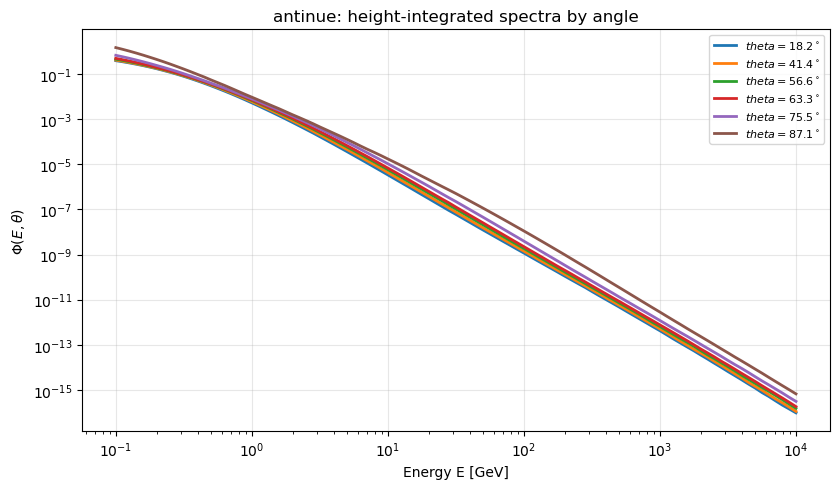

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\flux_vs_angle_antinue.png


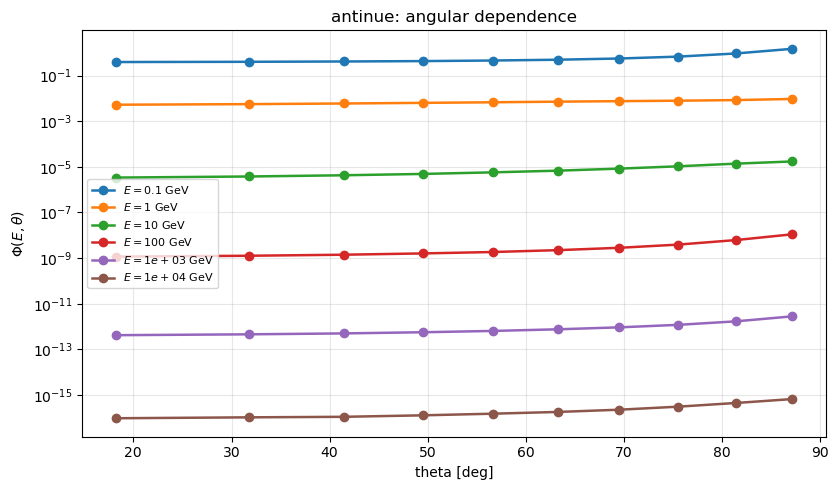

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\height_energy_map_antinue_flux.png


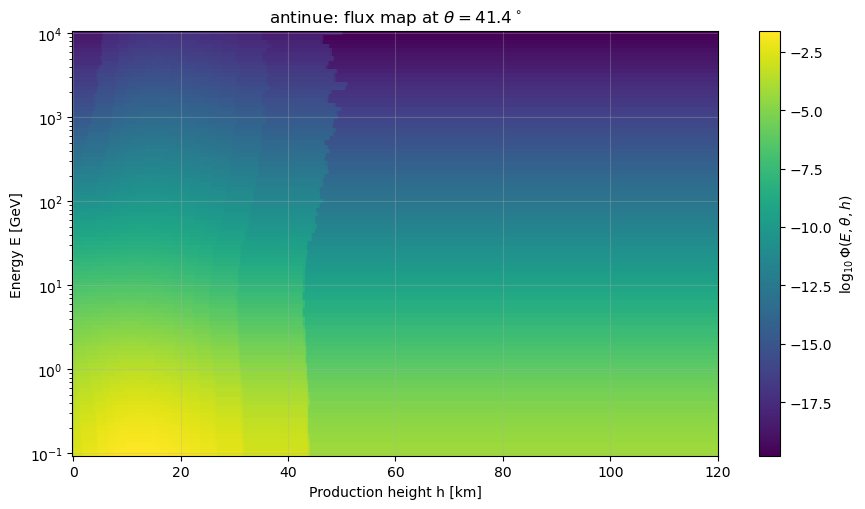

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\spectra_by_angle_antinumu.png


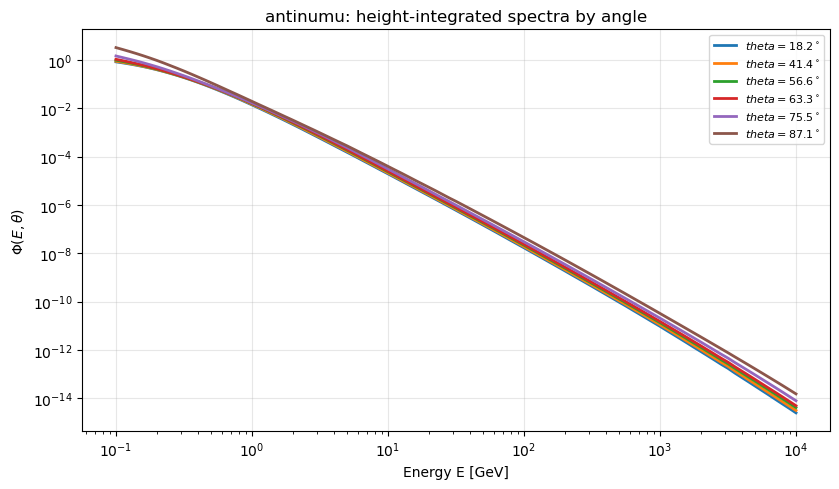

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\flux_vs_angle_antinumu.png


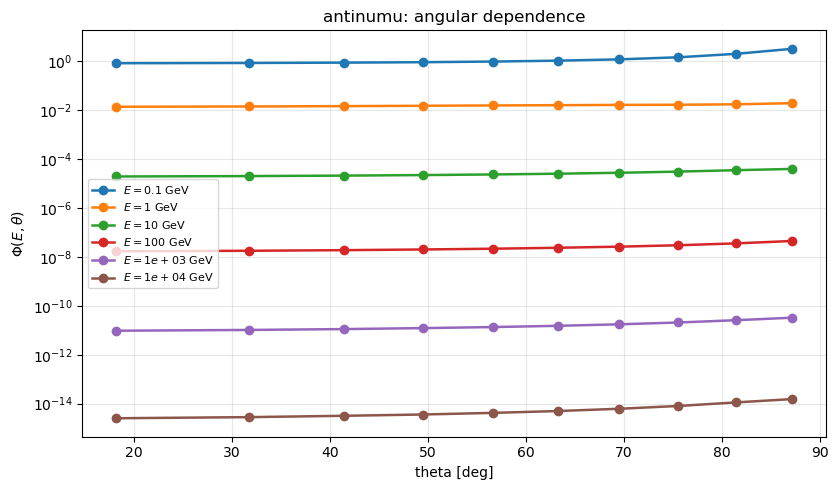

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\height_energy_map_antinumu_flux.png


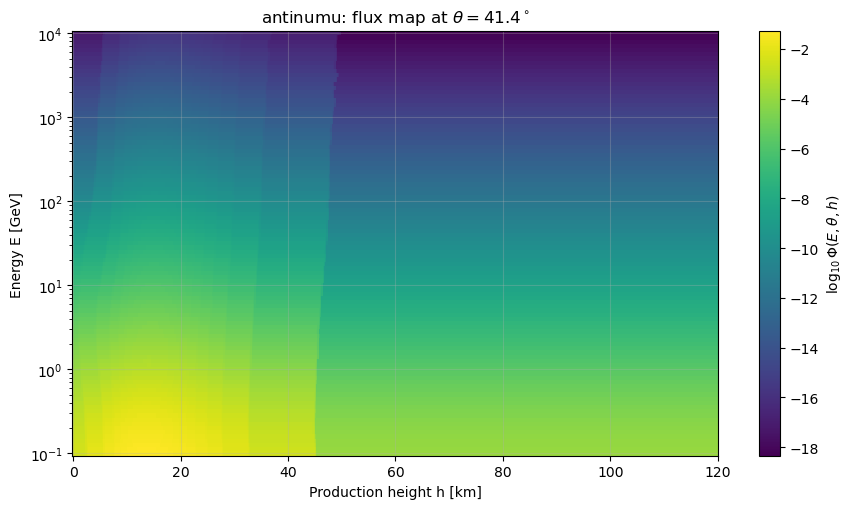

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\spectra_by_angle_antinutau.png


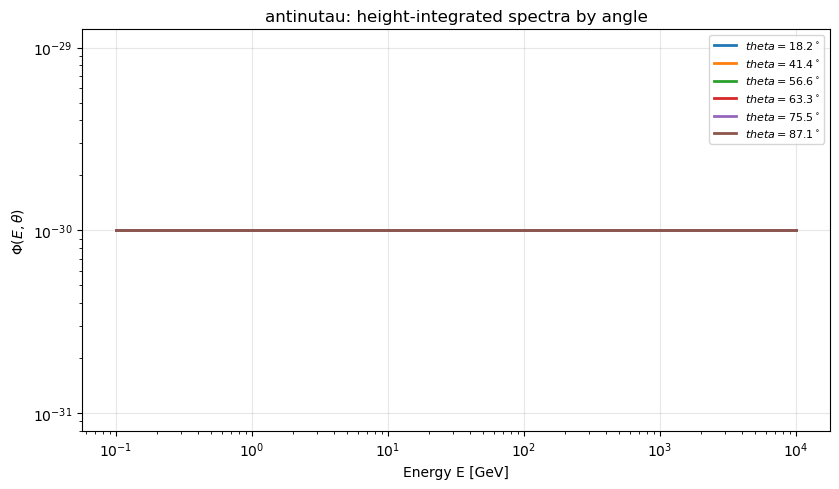

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\flux_vs_angle_antinutau.png


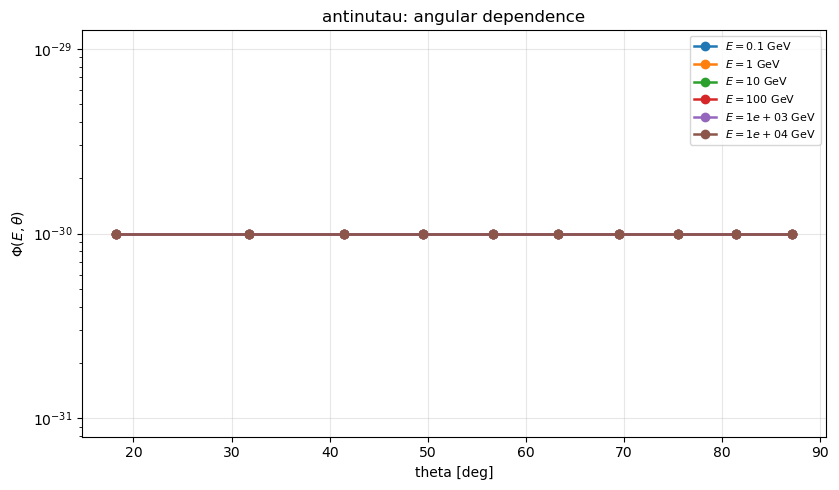

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\height_energy_map_antinutau_flux.png


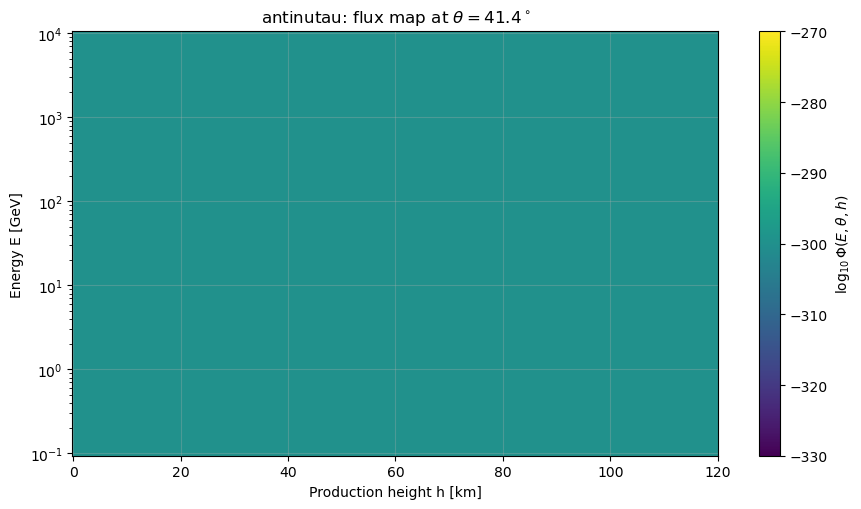

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\spectra_by_angle_nue.png


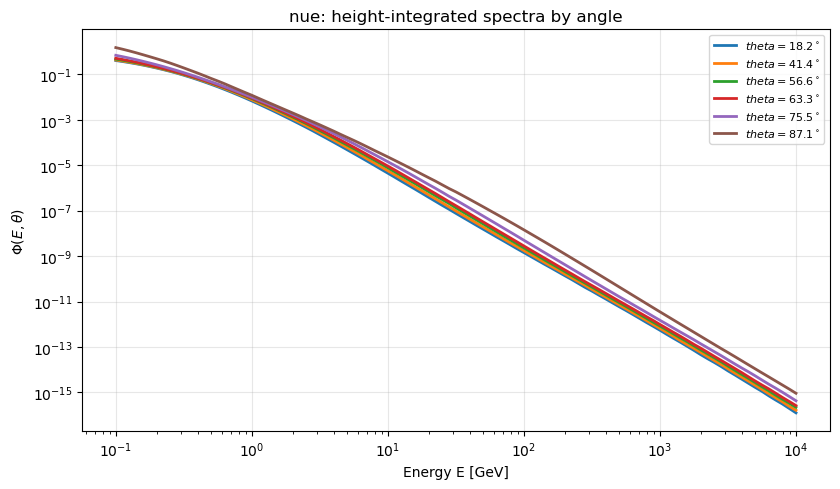

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\flux_vs_angle_nue.png


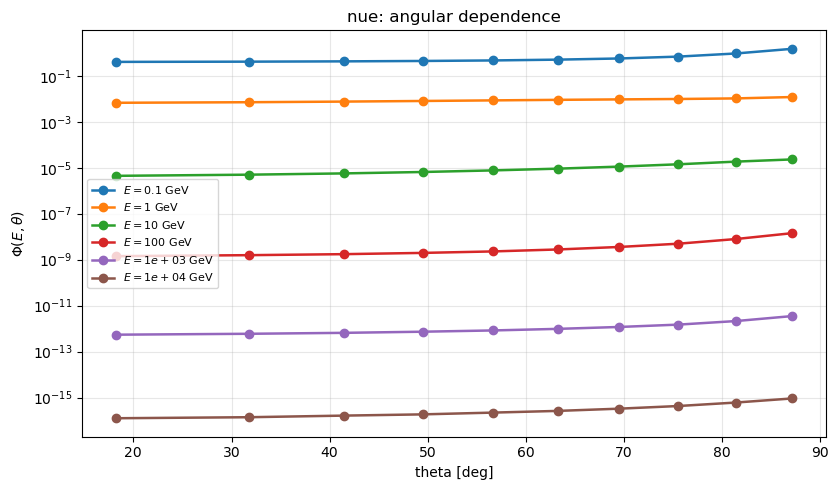

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\height_energy_map_nue_flux.png


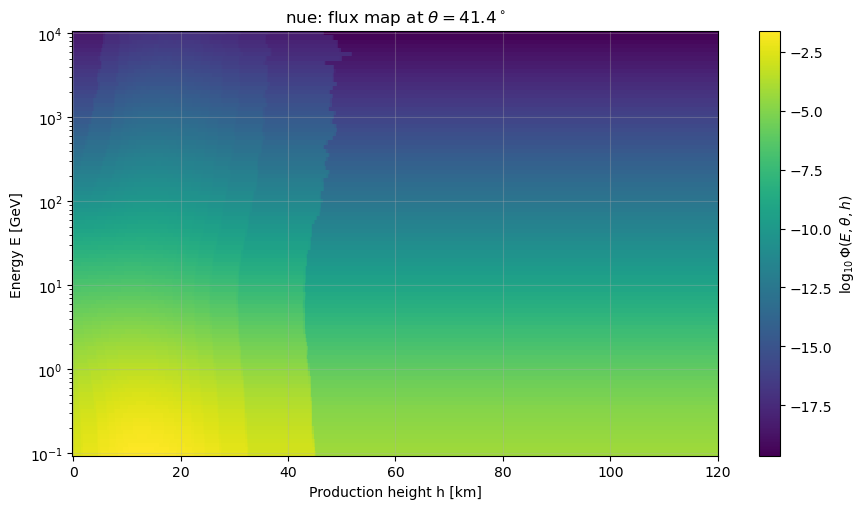

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\spectra_by_angle_numu.png


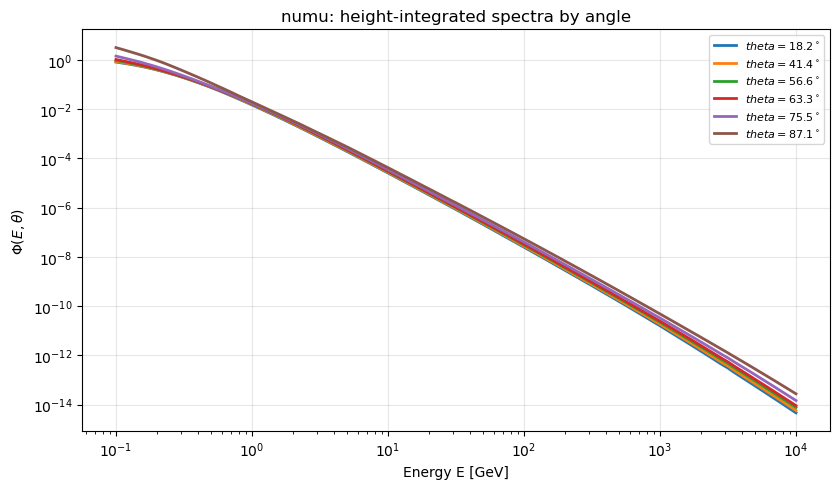

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\flux_vs_angle_numu.png


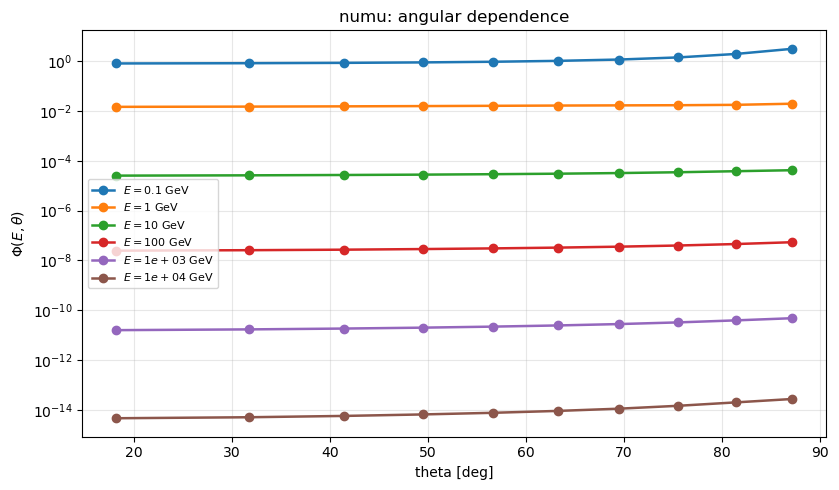

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\height_energy_map_numu_flux.png


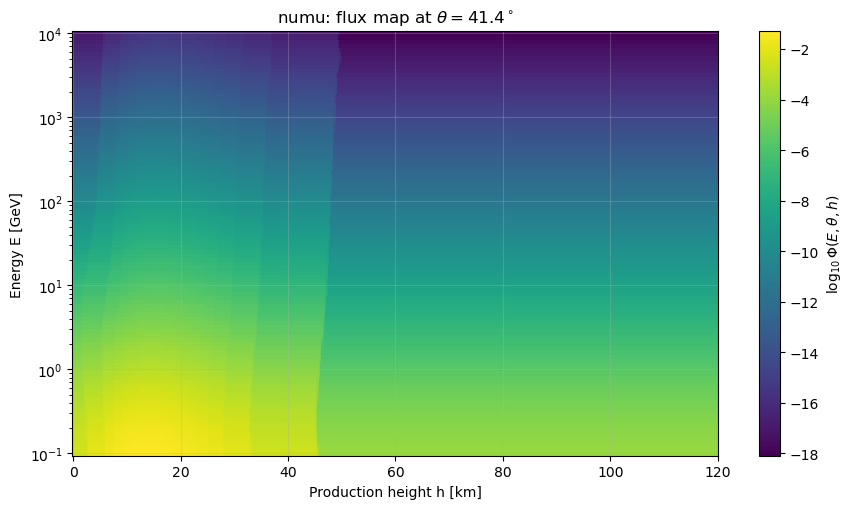

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\spectra_by_angle_nutau.png


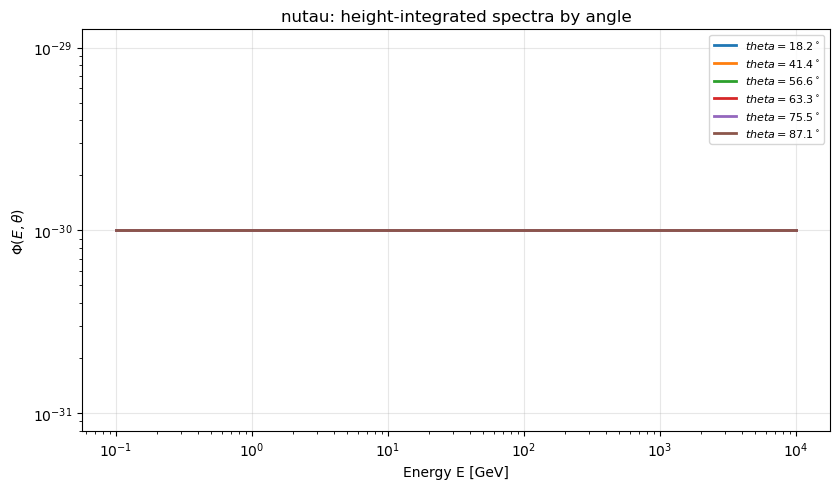

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\flux_vs_angle_nutau.png


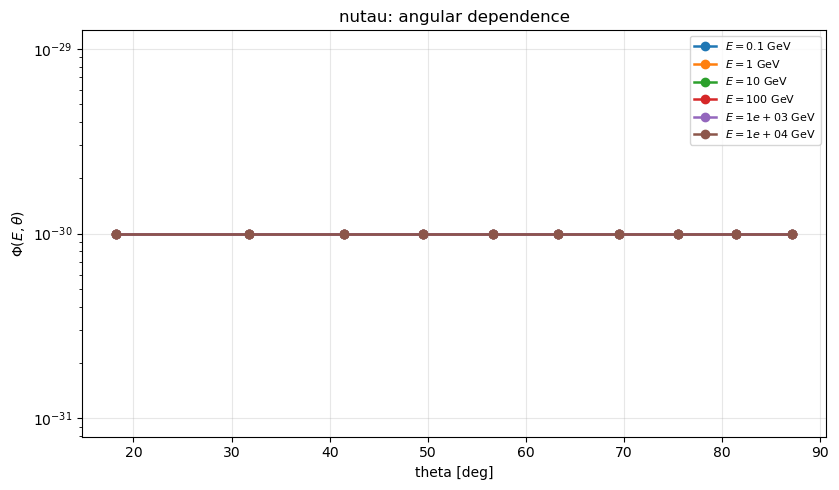

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\height_energy_map_nutau_flux.png


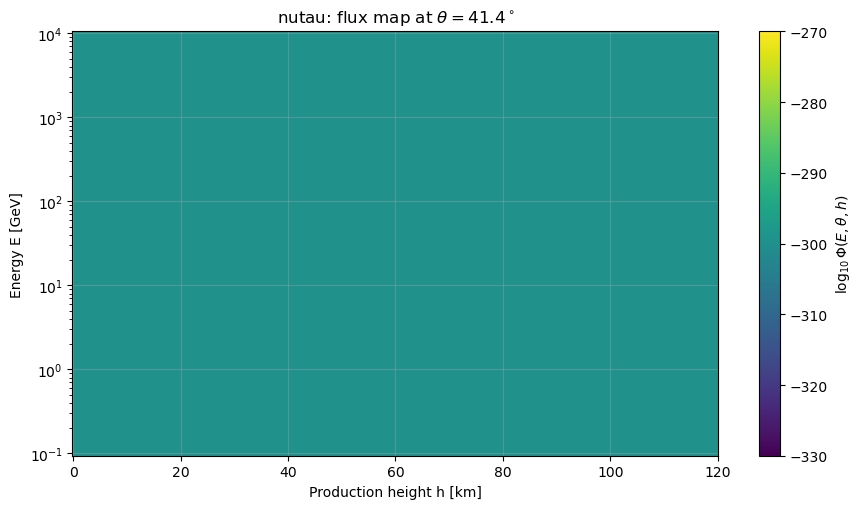

In [50]:
def plot_all_particles_overview(data):
    figs = []
    for particle in sorted(data.keys()):
        figs.append(plot_spectra_by_angle(data, particle=particle, max_angles=N_ANGLE_CURVES))
        figs.append(plot_flux_vs_angle(data, particle=particle, max_energies=N_ENERGY_CURVES))
        figs.append(plot_height_energy_map(data, particle=particle, theta_deg=DEFAULT_THETA_DEG, quantity="flux"))
    return figs

# Uncomment when you want the full overview for every particle.
all_overview_figures = plot_all_particles_overview(data)


## 15. Integrated Flux Robustness Checks

This section adapts the weighted-robustness diagnostic used in the CORSIKA notebooks to the Honda flux grids. Here the ?weights? are not Monte Carlo event weights, but positive flux contributions from grid cells. The diagnostic integrates the differential flux into three one-dimensional profiles: the neutrino energy spectrum integrated over height and angle, the production-height profile integrated over energy and angle, and the angular profile integrated over energy and height.

For each bin it also computes a concentration-style relative uncertainty, $\sqrt{\sum w_i^2}/\sum w_i$, and an effective support, $N_{eff}=(\sum_i w_i)^2/\sum_i w_i^2$. Large relative values indicate that a bin is dominated by a small number of grid cells or species contributions.


Integrated flux robustness diagnostics
------------------------------------------------------------------------
Particles included: ['nue', 'numu', 'nutau', 'antinue', 'antinumu', 'antinutau']
Angular integration mode: solid_angle
Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\figure_007.png


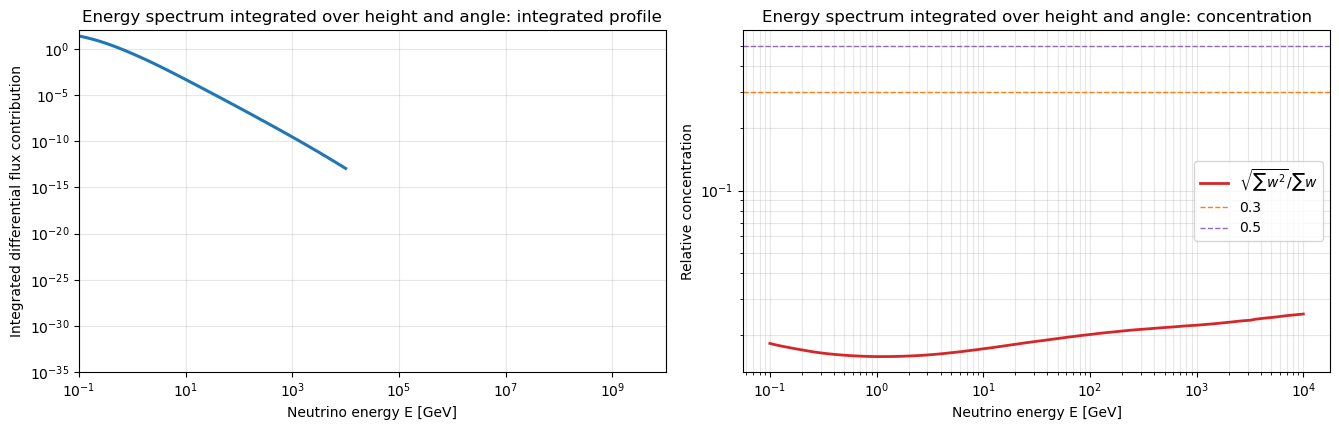

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\figure_008.png


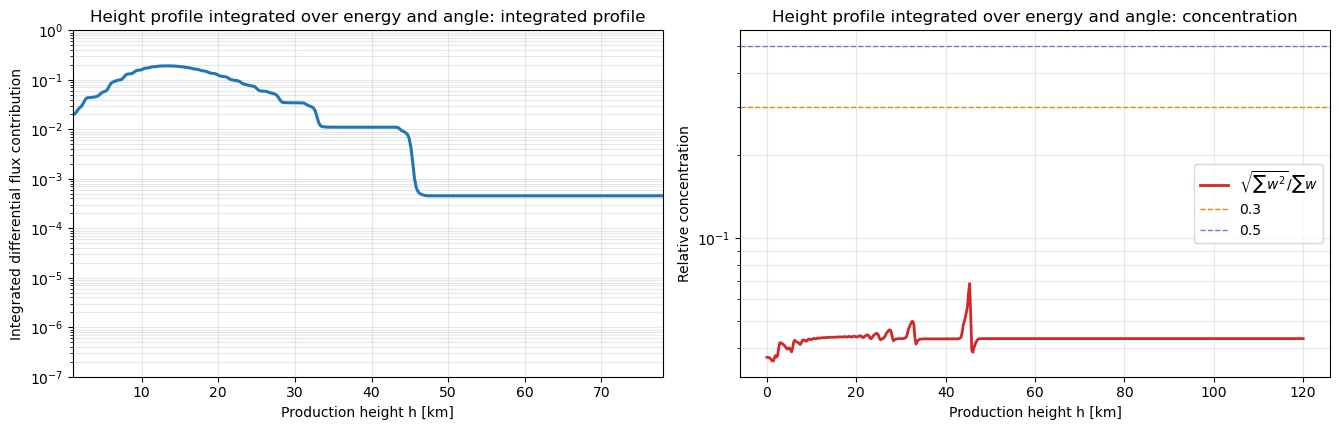

Saved figure: V:\output\analysis\atmosphere\analysis_atmospher1_honda_flux\figure_009.png


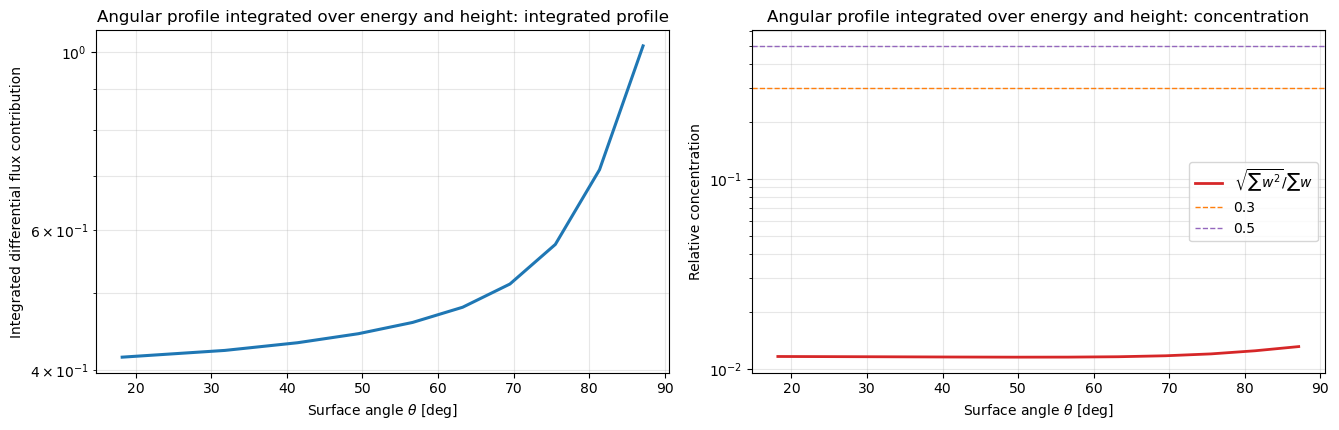

,profile,total_integrated_contribution,median_relative_concentration,min_n_eff
0,energy,150.719933,0.018693,1558.954478
1,height,14.197797,0.043149,213.849875
2,angle,5.476907,0.011587,5841.013566


Most concentrated energy bins


,x,sum_weights,sum_weights2,relative_concentration,n_eff
100,10000.000000,1.122932e-13,8.088603e-30,0.025327,1558.954478
99,8912.500000,1.690128e-13,1.811220e-29,0.025181,1577.131335
98,7943.299805,2.541951e-13,4.049427e-29,0.025034,1595.661773
97,7079.500000,3.811948e-13,9.003182e-29,0.024891,1613.979252
96,6309.600098,5.705291e-13,1.988319e-28,0.024715,1637.078683
95,5623.399902,8.521360e-13,4.366683e-28,0.024523,1662.900152
94,5011.899902,1.271803e-12,9.603009e-28,0.024366,1684.349133
93,4466.799805,1.893918e-12,2.106969e-27,0.024236,1702.409400
92,3981.100098,2.814659e-12,4.591257e-27,0.024074,1725.520529
91,3548.100098,4.176150e-12,9.956561e-27,0.023893,1751.632067


Most concentrated height bins


,x,sum_weights,sum_weights2,relative_concentration,n_eff
189,45.360001,0.002252,2.372197e-08,0.068383,213.849875
188,45.119999,0.004467,8.036147e-08,0.063465,248.271103
187,44.879997,0.006793,1.474469e-07,0.056527,312.961900
186,44.639999,0.008078,1.891064e-07,0.053832,345.073187
190,45.599998,0.001012,2.832566e-09,0.052588,361.598848
185,44.399998,0.008636,1.981445e-07,0.051541,376.434096
136,32.639999,0.023639,1.388235e-06,0.049843,402.527699
135,32.399998,0.027125,1.818574e-06,0.049717,404.573041
184,44.160000,0.009098,2.045541e-07,0.049709,404.692178
134,32.160000,0.028486,1.933623e-06,0.048816,419.646343


Most concentrated angle bins


,x,sum_weights,sum_weights2,relative_concentration,n_eff
9,87.134018,1.018918,0.000178,0.013084,5841.013566
8,81.373077,0.713267,0.000079,0.012438,6463.547924
7,75.522491,0.575086,0.000047,0.011976,6972.776182
6,69.512688,0.513086,0.000036,0.011706,7297.432507
0,18.194874,0.415613,0.000023,0.011605,7425.497263
5,63.256317,0.479903,0.000031,0.011569,7470.868060
1,31.788328,0.423771,0.000024,0.011565,7477.063301
2,41.409622,0.433256,0.000025,0.011531,7520.624942
4,56.632988,0.459344,0.000028,0.011518,7538.292417
3,49.458401,0.444664,0.000026,0.011511,7547.451461


In [51]:
def grid_widths_from_centers(grid):
    """Estimate bin widths from a monotonic grid of bin centers."""
    x = to_numpy(grid).astype(float)
    if x.size == 1:
        return np.ones_like(x)
    edges = np.empty(x.size + 1, dtype=float)
    edges[1:-1] = 0.5 * (x[:-1] + x[1:])
    edges[0] = x[0] - 0.5 * (x[1] - x[0])
    edges[-1] = x[-1] + 0.5 * (x[-1] - x[-2])
    widths = np.diff(edges)
    return np.maximum(widths, 0.0)


def angular_widths(theta_deg, mode=ROBUSTNESS_ANGLE_MODE):
    """Return angular integration weights for theta-grid centers."""
    theta = to_numpy(theta_deg).astype(float)
    dtheta_rad = np.deg2rad(grid_widths_from_centers(theta))
    if mode == "solid_angle":
        return 2.0 * np.pi * np.sin(np.deg2rad(theta)) * dtheta_rad
    if mode == "linear":
        return dtheta_rad
    raise ValueError("mode must be 'solid_angle' or 'linear'.")


def effective_support_from_sums(sum_w, sum_w2):
    """Compute effective support from weighted sums."""
    return np.divide(sum_w**2, sum_w2, out=np.zeros_like(sum_w, dtype=float), where=sum_w2 > 0)


def relative_concentration(sum_w, sum_w2):
    """Compute sqrt(sum_w2) / sum_w, with NaN where the bin is empty."""
    return np.divide(np.sqrt(sum_w2), sum_w, out=np.full_like(sum_w, np.nan, dtype=float), where=sum_w > 0)


def integrated_profiles_for_particle(data, particle):
    """Return integrated energy, height, and angular profiles for one Honda particle group."""
    group = data[particle]
    E = to_numpy(group["E_grid_GeV"]).astype(float)
    theta = to_numpy(group["theta_grid_deg"]).astype(float)
    h = to_numpy(group["h_grid_km"]).astype(float)
    phi_theta_E_h = to_numpy(group["phi_E_theta_h"]).astype(float)

    # Convert from [theta, energy, height] to [energy, theta, height].
    phi = np.transpose(np.maximum(phi_theta_E_h, 0.0), (1, 0, 2))

    dE = grid_widths_from_centers(E)
    dOmega = angular_widths(theta)
    dh = grid_widths_from_centers(h)

    energy_contrib = phi * dOmega[None, :, None] * dh[None, None, :]
    height_contrib = phi * dE[:, None, None] * dOmega[None, :, None]
    angle_contrib = phi * dE[:, None, None] * dh[None, None, :]

    energy_sum = energy_contrib.sum(axis=(1, 2))
    energy_sum2 = (energy_contrib**2).sum(axis=(1, 2))
    height_sum = height_contrib.sum(axis=(0, 1))
    height_sum2 = (height_contrib**2).sum(axis=(0, 1))
    angle_sum = angle_contrib.sum(axis=(0, 2))
    angle_sum2 = (angle_contrib**2).sum(axis=(0, 2))

    return {
        "particle": particle,
        "E": E,
        "theta": theta,
        "h": h,
        "energy_sum": energy_sum,
        "energy_sum2": energy_sum2,
        "height_sum": height_sum,
        "height_sum2": height_sum2,
        "angle_sum": angle_sum,
        "angle_sum2": angle_sum2,
    }


def combine_profile_stats(profile_list, axis):
    """Combine per-particle integrated profiles into total profile statistics."""
    if axis == "energy":
        x = profile_list[0]["E"]
        sum_key, sum2_key = "energy_sum", "energy_sum2"
    elif axis == "height":
        x = profile_list[0]["h"]
        sum_key, sum2_key = "height_sum", "height_sum2"
    elif axis == "angle":
        x = profile_list[0]["theta"]
        sum_key, sum2_key = "angle_sum", "angle_sum2"
    else:
        raise ValueError("axis must be 'energy', 'height', or 'angle'.")

    sum_w = np.zeros_like(x, dtype=float)
    sum_w2 = np.zeros_like(x, dtype=float)
    for profile in profile_list:
        sum_w += profile[sum_key]
        sum_w2 += profile[sum2_key]

    return pd.DataFrame(
        {
            "x": x,
            "sum_weights": sum_w,
            "sum_weights2": sum_w2,
            "relative_concentration": relative_concentration(sum_w, sum_w2),
            "n_eff": effective_support_from_sums(sum_w, sum_w2),
        }
    )


def plot_integrated_profile_with_robustness(stats, x_label, title, *, logx=False, limx=False, limy=False):
    """Plot integrated profile and concentration diagnostics for one axis."""
    fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.4))
    x = stats["x"].to_numpy(dtype=float)

    axes[0].plot(x, clamp_positive(stats["sum_weights"].to_numpy()), linewidth=2.2)
    axes[0].set_ylabel("Integrated differential flux contribution")
    axes[0].set_title(f"{title}: integrated profile")
    axes[0].grid(True, which="both", alpha=0.3)
    if limx:
        axes[0].set_xlim(limx[0], limx[1])
    if limy:
        axes[0].set_ylim(limy[0], limy[1])
    axes[1].plot(x, stats["relative_concentration"], linewidth=2.0, color="tab:red", label=r"$\sqrt{\sum w^2}/\sum w$")
    axes[1].axhline(0.3, color="tab:orange", linestyle="--", lw=1.0, label="0.3")
    axes[1].axhline(0.5, color="tab:purple", linestyle="--", lw=1.0, label="0.5")
    axes[1].set_ylabel("Relative concentration")
    axes[1].set_title(f"{title}: concentration")
    axes[1].legend()
    axes[1].grid(True, which="both", alpha=0.3)

    for ax in axes:
        ax.set_xlabel(x_label)
        if logx:
            ax.set_xscale("log")
        ax.set_yscale("log")

    fig.tight_layout()
    save_and_show(output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
    return fig


if not ROBUSTNESS_PARTICLES:
    print("No neutrino particle groups are available for robustness diagnostics.")
else:
    print("Integrated flux robustness diagnostics")
    print("-" * 72)
    print(f"Particles included: {ROBUSTNESS_PARTICLES}")
    print(f"Angular integration mode: {ROBUSTNESS_ANGLE_MODE}")

    robustness_profiles = [integrated_profiles_for_particle(data, particle) for particle in ROBUSTNESS_PARTICLES]
    energy_stats = combine_profile_stats(robustness_profiles, "energy")
    height_stats = combine_profile_stats(robustness_profiles, "height")
    angle_stats = combine_profile_stats(robustness_profiles, "angle")

    plot_integrated_profile_with_robustness(
        energy_stats,
        "Neutrino energy E [GeV]",
        "Energy spectrum integrated over height and angle",
        logx=True,
        limx=(1e-1,1e10),
        limy=(1e-35,1e2)
    )
    plot_integrated_profile_with_robustness(
        height_stats,
        "Production height h [km]",
        "Height profile integrated over energy and angle",
        logx=False,
        limx=(1,78),
        limy=(1e-7,1e-0)
    )
    plot_integrated_profile_with_robustness(
        angle_stats,
        r"Surface angle $\theta$ [deg]",
        "Angular profile integrated over energy and height",
        logx=False,
        limx=None,
        limy=None
    )

    summary = pd.DataFrame(
        [
            {
                "profile": "energy",
                "total_integrated_contribution": energy_stats["sum_weights"].sum(),
                "median_relative_concentration": energy_stats["relative_concentration"].median(),
                "min_n_eff": energy_stats.loc[energy_stats["sum_weights"] > 0, "n_eff"].min(),
            },
            {
                "profile": "height",
                "total_integrated_contribution": height_stats["sum_weights"].sum(),
                "median_relative_concentration": height_stats["relative_concentration"].median(),
                "min_n_eff": height_stats.loc[height_stats["sum_weights"] > 0, "n_eff"].min(),
            },
            {
                "profile": "angle",
                "total_integrated_contribution": angle_stats["sum_weights"].sum(),
                "median_relative_concentration": angle_stats["relative_concentration"].median(),
                "min_n_eff": angle_stats.loc[angle_stats["sum_weights"] > 0, "n_eff"].min(),
            },
        ]
    )
    display(summary)

    print("Most concentrated energy bins")
    display(energy_stats.sort_values("relative_concentration", ascending=False).head(15))
    print("Most concentrated height bins")
    display(height_stats.sort_values("relative_concentration", ascending=False).head(15))
    print("Most concentrated angle bins")
    display(angle_stats.sort_values("relative_concentration", ascending=False).head(15))
